In [1]:
#cell 1
import torch
import copy
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
%matplotlib inline

# Add the parent directory to the Python path - bad practice, but it's just for the example
import sys
sys.path.append("/home/heydari/FHHI-XAI/")

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from src.glocal_analysis import run_analysis 
from src.datasets.flood_dataset import FloodDataset
from src.datasets.DLR_dataset import DatasetDLR
from src.plot_crp_explanations import plot_explanations, plot_one_image_explanation
from src.minio_client import MinIOClient
from LCRP.models import get_model 
from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES

import logging
# Suppress specific noisy libraries if needed
logging.getLogger("PIL").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("numba").setLevel(logging.WARNING)



/home/heydari/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#cell 2

# --- imports
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import tqdm
from src.datasets.flood_dataset import FloodDataset

# --- data / transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

root_dir = "../data/BRK-data/"
dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded dataset:', type(dataset))
print('len(dataset) =', len(dataset))

# --- device
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# --- model / checkpoint
model_name = "pidnet"
ckpt_path = "../models/flood_model.pt"

# ========= HACK: prevent get_model()/get_pidnet() from trying to strictly load its OWN checkpoint =========
# Some internal path calls `model.load_state_dict(torch.load(cfg["ckpt_path"]))` with strict=True,
# which raises due to "model." prefix or different head. We temporarily force:
#   - torch.load -> always map to CPU (safe on CPU-only)
#   - nn.Module.load_state_dict -> always use strict=False
_orig_torch_load = torch.load
_orig_load_state_dict = torch.nn.Module.load_state_dict

def _cpu_load(*args, **kwargs):
    kwargs.setdefault("map_location", "cpu")
    return _orig_torch_load(*args, **kwargs)

def _lenient_load_state_dict(self, state_dict, strict=True):
    # Force non-strict to avoid internal RuntimeError during model construction
    return _orig_load_state_dict(self, state_dict, strict=False)

torch.load = _cpu_load
torch.nn.Module.load_state_dict = _lenient_load_state_dict
try:
    # Build the model; any internal checkpoint load will be lenient and won't crash
    model = get_model(model_name=model_name, device=device, classes=2)
finally:
    # Restore patched functions
    torch.load = _orig_torch_load
    torch.nn.Module.load_state_dict = _orig_load_state_dict

# ========= Now load YOUR checkpoint properly (handle "model." / "module." prefixes) =========
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        for k in ("state_dict", "model_state", "model", "net", "module"):
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj

def _strip_prefix(sd, prefix):
    if any(k.startswith(prefix) for k in sd.keys()):
        return {k[len(prefix):]: v for k, v in sd.items()}
    return sd

raw_sd = torch.load(ckpt_path, map_location="cpu")
sd = _extract_state_dict(raw_sd)
sd = _strip_prefix(sd, "model.")
sd = _strip_prefix(sd, "module.")

missing, unexpected = model.load_state_dict(sd, strict=False)
if missing:
    print("[load_state_dict] Missing keys:", len(missing))
    # print(missing)  # uncomment for full list
if unexpected:
    print("[load_state_dict] Unexpected keys:", len(unexpected))
    # print(unexpected)  # uncomment for full list

# finalize
model.to(device)
model.eval()
model.augment = False

output_dir = "../examples/output/crp/pidnet_flood_BRK"
print(f"Model ready on {device}. Output dir: {output_dir}")


Loaded dataset: <class 'src.datasets.flood_dataset.FloodDataset'>
len(dataset) = 1322
Loaded checkpoint ../models/flood_model.pt
Model ready on cuda:0. Output dir: ../examples/output/crp/pidnet_flood_BRK


In [17]:
#cell 3
# --- validation evaluation: Mean IoU, Pixel Acc, Mean Acc, per-class IoU
import numpy as np
import torch
import torch.nn.functional as F
from types import SimpleNamespace
from pathlib import Path as PathlibPath
from torch.utils.data import DataLoader
from tqdm import tqdm
from src.datasets.flood_dataset import FloodDataset
from src.utils.utils import get_confusion_matrix

# minimal config matching the previous general_flood_v3 settings
cfg = SimpleNamespace(
    DATASET=SimpleNamespace(
        NUM_CLASSES=2,
    ),
    MODEL=SimpleNamespace(
        NUM_OUTPUTS=1,
        ALIGN_CORNERS=True,
    ),
    TEST=SimpleNamespace(
        OUTPUT_INDEX=-1,
        BASE_SIZE=2048,
        IMAGE_SIZE=[1280, 720],
    ),
    TRAIN=SimpleNamespace(
        IGNORE_LABEL=-1,
        SCALE_FACTOR=16,
    ),
)

val_root = PathlibPath("../data/BRK-data/").resolve()
val_dataset = FloodDataset(
    root_dir=str(val_root),
    split="val",
    transform=transform,
)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

# quick sanity check on paired counts

print("Validation samples (paired):", len(val_dataset))

def evaluate_val(model, loader, cfg, device=device):
    model.eval()
    confusion = np.zeros((cfg.DATASET.NUM_CLASSES, cfg.DATASET.NUM_CLASSES))
    with torch.no_grad():
        for image, label, _, _, _, _ in tqdm(loader, total=len(loader), desc="val"):
            image = image.to(device)
            label = label.to(device)

            pred = val_dataset.single_scale_inference(cfg, model, image)
            if pred.shape[-2:] != label.shape[-2:]:
                pred = F.interpolate(
                    pred, label.shape[-2:], mode="bilinear", align_corners=cfg.MODEL.ALIGN_CORNERS
                )

            confusion += get_confusion_matrix(
                label, pred, label.size(), cfg.DATASET.NUM_CLASSES, cfg.TRAIN.IGNORE_LABEL
            )

    pos = confusion.sum(1)
    res = confusion.sum(0)
    tp = np.diag(confusion)
    pixel_acc = tp.sum() / pos.sum()
    mean_acc = (tp / np.maximum(1.0, pos)).mean()
    class_iou = tp / np.maximum(1.0, pos + res - tp)
    mean_iou = class_iou.mean()

    print(f"Pixel_Acc: {pixel_acc:.4f}")
    print(f"Mean_Acc: {mean_acc:.4f}")
    print(f"Mean_IoU: {mean_iou:.4f}")
    for idx, iou in enumerate(class_iou):
        print(f"Class {idx} IoU: {iou:.4f}")

    return mean_iou, class_iou, pixel_acc, mean_acc



Validation samples (paired): 244


In [4]:
#cell 4

# --- validation evaluation: Mean IoU, Pixel Acc, Mean Acc, per-class IoU
import numpy as np
import torch
import torch.nn.functional as F
from types import SimpleNamespace
from pathlib import Path as PathlibPath
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.datasets.flood_dataset_metrics import FloodDataset
from src.utils.utils import get_confusion_matrix

# minimal config (only things we actually need here)
cfg = SimpleNamespace(
    DATASET=SimpleNamespace(
        NUM_CLASSES=2,
    ),
    MODEL=SimpleNamespace(
        NUM_OUTPUTS=1,
        ALIGN_CORNERS=True,
    ),
    TEST=SimpleNamespace(
        OUTPUT_INDEX=-1,
        BASE_SIZE=2048,
        IMAGE_SIZE=[1280, 720],
    ),
    TRAIN=SimpleNamespace(
        IGNORE_LABEL=-1,   # just a default; real value comes from dataset
        SCALE_FACTOR=16,
    ),
)

# root should point to folder that either contains "General_Flood_v3"
# or is itself the General_Flood_v3 folder
val_root = PathlibPath("../data").resolve()

val_dataset = FloodDataset(
    root_dir=str(val_root),
    split="val",
    transform=transform,
    multi_scale=False,
    flip=False,
    # NOTE: we do NOT pass ignore_label here -> use FloodDataset's default
    base_size=cfg.TEST.BASE_SIZE,
    crop_size=(cfg.TEST.IMAGE_SIZE[1], cfg.TEST.IMAGE_SIZE[0]),
    scale_factor=cfg.TRAIN.SCALE_FACTOR,
    return_or_dims=True,
)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

# quick sanity check on paired counts + ignore label
print("Validation samples (paired):", len(val_dataset))
print("Dataset ignore_label:", getattr(val_dataset, "ignore_label", None))

def evaluate_val(model, loader, cfg, device):
    model.eval()
    confusion = np.zeros((cfg.DATASET.NUM_CLASSES, cfg.DATASET.NUM_CLASSES))
    # take ignore_label from the dataset, fall back to cfg if missing
    ignore_label = getattr(loader.dataset, "ignore_label", cfg.TRAIN.IGNORE_LABEL)

    with torch.no_grad():
        # optional: one-time debug flag to inspect ignore pixels
        debug_once = True

        for image, label, _, _, _, _ in tqdm(loader, total=len(loader), desc="val"):
            image = image.to(device)
            label = label.to(device)

            pred = loader.dataset.single_scale_inference(cfg, model, image)
            if pred.shape[-2:] != label.shape[-2:]:
                pred = F.interpolate(
                    pred,
                    label.shape[-2:],
                    mode="bilinear",
                    align_corners=cfg.MODEL.ALIGN_CORNERS,
                )

            # Optional debug: see how many pixels are actually ignored
            if debug_once:
                n_ignore = (label == ignore_label).sum().item()
                n_total = label.numel()
                print(f"Ignore pixels in first batch: {n_ignore}/{n_total}")
                debug_once = False

            confusion += get_confusion_matrix(
                label,
                pred,
                label.size(),
                cfg.DATASET.NUM_CLASSES,
                ignore_label,   # <-- using dataset's ignore_label
            )

    pos = confusion.sum(1)
    res = confusion.sum(0)
    tp = np.diag(confusion)

    pixel_acc = tp.sum() / pos.sum()
    mean_acc = (tp / np.maximum(1.0, pos)).mean()
    class_iou = tp / np.maximum(1.0, pos + res - tp)
    mean_iou = class_iou.mean()

    print(f"Pixel_Acc: {pixel_acc:.4f}")
    print(f"Mean_Acc:  {mean_acc:.4f}")
    print(f"Mean_IoU:  {mean_iou:.4f}")
    for idx, iou in enumerate(class_iou):
        print(f"Class {idx} IoU: {iou:.4f}")

    return mean_iou, class_iou, pixel_acc, mean_acc


Validation samples (paired): 244
Dataset ignore_label: -1


In [5]:
#cell 5
mean_iou, class_iou, pixel_acc, mean_acc = evaluate_val(model, val_loader, cfg, device)
print("Returned:", mean_iou, class_iou, pixel_acc, mean_acc)


val:   0%|          | 1/244 [00:01<04:16,  1.06s/it]

Ignore pixels in first batch: 0/921600


val: 100%|██████████| 244/244 [00:56<00:00,  4.30it/s]

Pixel_Acc: 0.9489
Mean_Acc:  0.9253
Mean_IoU:  0.8796
Class 0 IoU: 0.9324
Class 1 IoU: 0.8268
Returned: 0.8796406315716103 [0.93244812 0.82683314] 0.9489228195440573 0.9253221105684474


In [ ]:
#cell 6

# --- imports
import torch
from torchvision import transforms
from src.datasets.flood_datase_crp import FloodDataset 
output_dir = "../examples/output/crp/CRP-BRK-NEW"
# --- data / transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

root_dir = "../data/BRK-data/"
dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded dataset:', type(dataset))
print('len(dataset) =', len(dataset))

run_analysis(model_name, model, dataset, output_dir=output_dir, device=device)

Loaded dataset: <class 'src.datasets.flood_datase_crp.FloodDataset'>
len(dataset) = 1322
torch.Size([3, 720, 1280])
MEMORY STARTING: 0.03GB (max: 0.03GB)
MEMORY AFTER FIGURE CREATION: 0.04GB (max: 0.04GB)
MEMORY BEFORE SEGMENTATION ATTR: 0.04GB (max: 0.04GB)


/home/heydari/.local/lib/python3.10/site-packages/torch/cuda/memory.py:282: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(
ERROR:LCRP.utils.crp:Prediction time: 0.1387789249420166, Backward time: 0.22460412979125977, Full attribution time: 0.23640751838684082
DEBUG:src.plot_crp_explanations:Time to compute conditional heatmaps: 0.00s


MEMORY AFTER SEGMENTATION ATTR: 0.04GB (max: 0.04GB)
MEMORY AFTER DETECTION/SEGMENTATION: 0.04GB (max: 0.04GB)
Concepts: torch.return_types.topk(
values=tensor([0.1129, 0.1022, 0.1016]),
indices=tensor([ 70, 116, 216]))
Computing reference images...
MEMORY BEFORE REF IMAGES: 0.04GB (max: 0.04GB)


ERROR:LCRP.utils.crp:Prediction time: 0.2098381519317627, Backward time: 0.47597694396972656, Full attribution time: 0.49727511405944824
ERROR:LCRP.utils.crp:Prediction time: 0.1380329132080078, Backward time: 0.3334972858428955, Full attribution time: 0.3446321487426758
ERROR:LCRP.utils.crp:Prediction time: 0.13672685623168945, Backward time: 0.3538703918457031, Full attribution time: 0.37881898880004883
ERROR:LCRP.utils.crp:Prediction time: 0.16551423072814941, Backward time: 0.3891468048095703, Full attribution time: 0.4024620056152344
ERROR:LCRP.utils.crp:Prediction time: 0.16771197319030762, Backward time: 0.4013557434082031, Full attribution time: 0.41723060607910156
ERROR:LCRP.utils.crp:Prediction time: 0.1322929859161377, Backward time: 0.32469701766967773, Full attribution time: 0.34107255935668945
ERROR:LCRP.utils.crp:Prediction time: 0.14026451110839844, Backward time: 0.3450901508331299, Full attribution time: 0.3550078868865967
ERROR:LCRP.utils.crp:Prediction time: 0.13319

MEMORY AFTER REF IMAGES: 0.04GB (max: 0.04GB)
Plotting...
MEMORY PLOTTING CONCEPT 0: 0.04GB (max: 0.04GB)
MEMORY PLOTTING CONCEPT 1: 0.04GB (max: 0.04GB)
MEMORY PLOTTING CONCEPT 2: 0.04GB (max: 0.04GB)


DEBUG:src.plot_crp_explanations:Time to plot: 0.59s


MEMORY PLOTTING CONCEPT 3: 0.04GB (max: 0.04GB)
MEMORY AFTER PLOTTING: 0.04GB (max: 0.04GB)


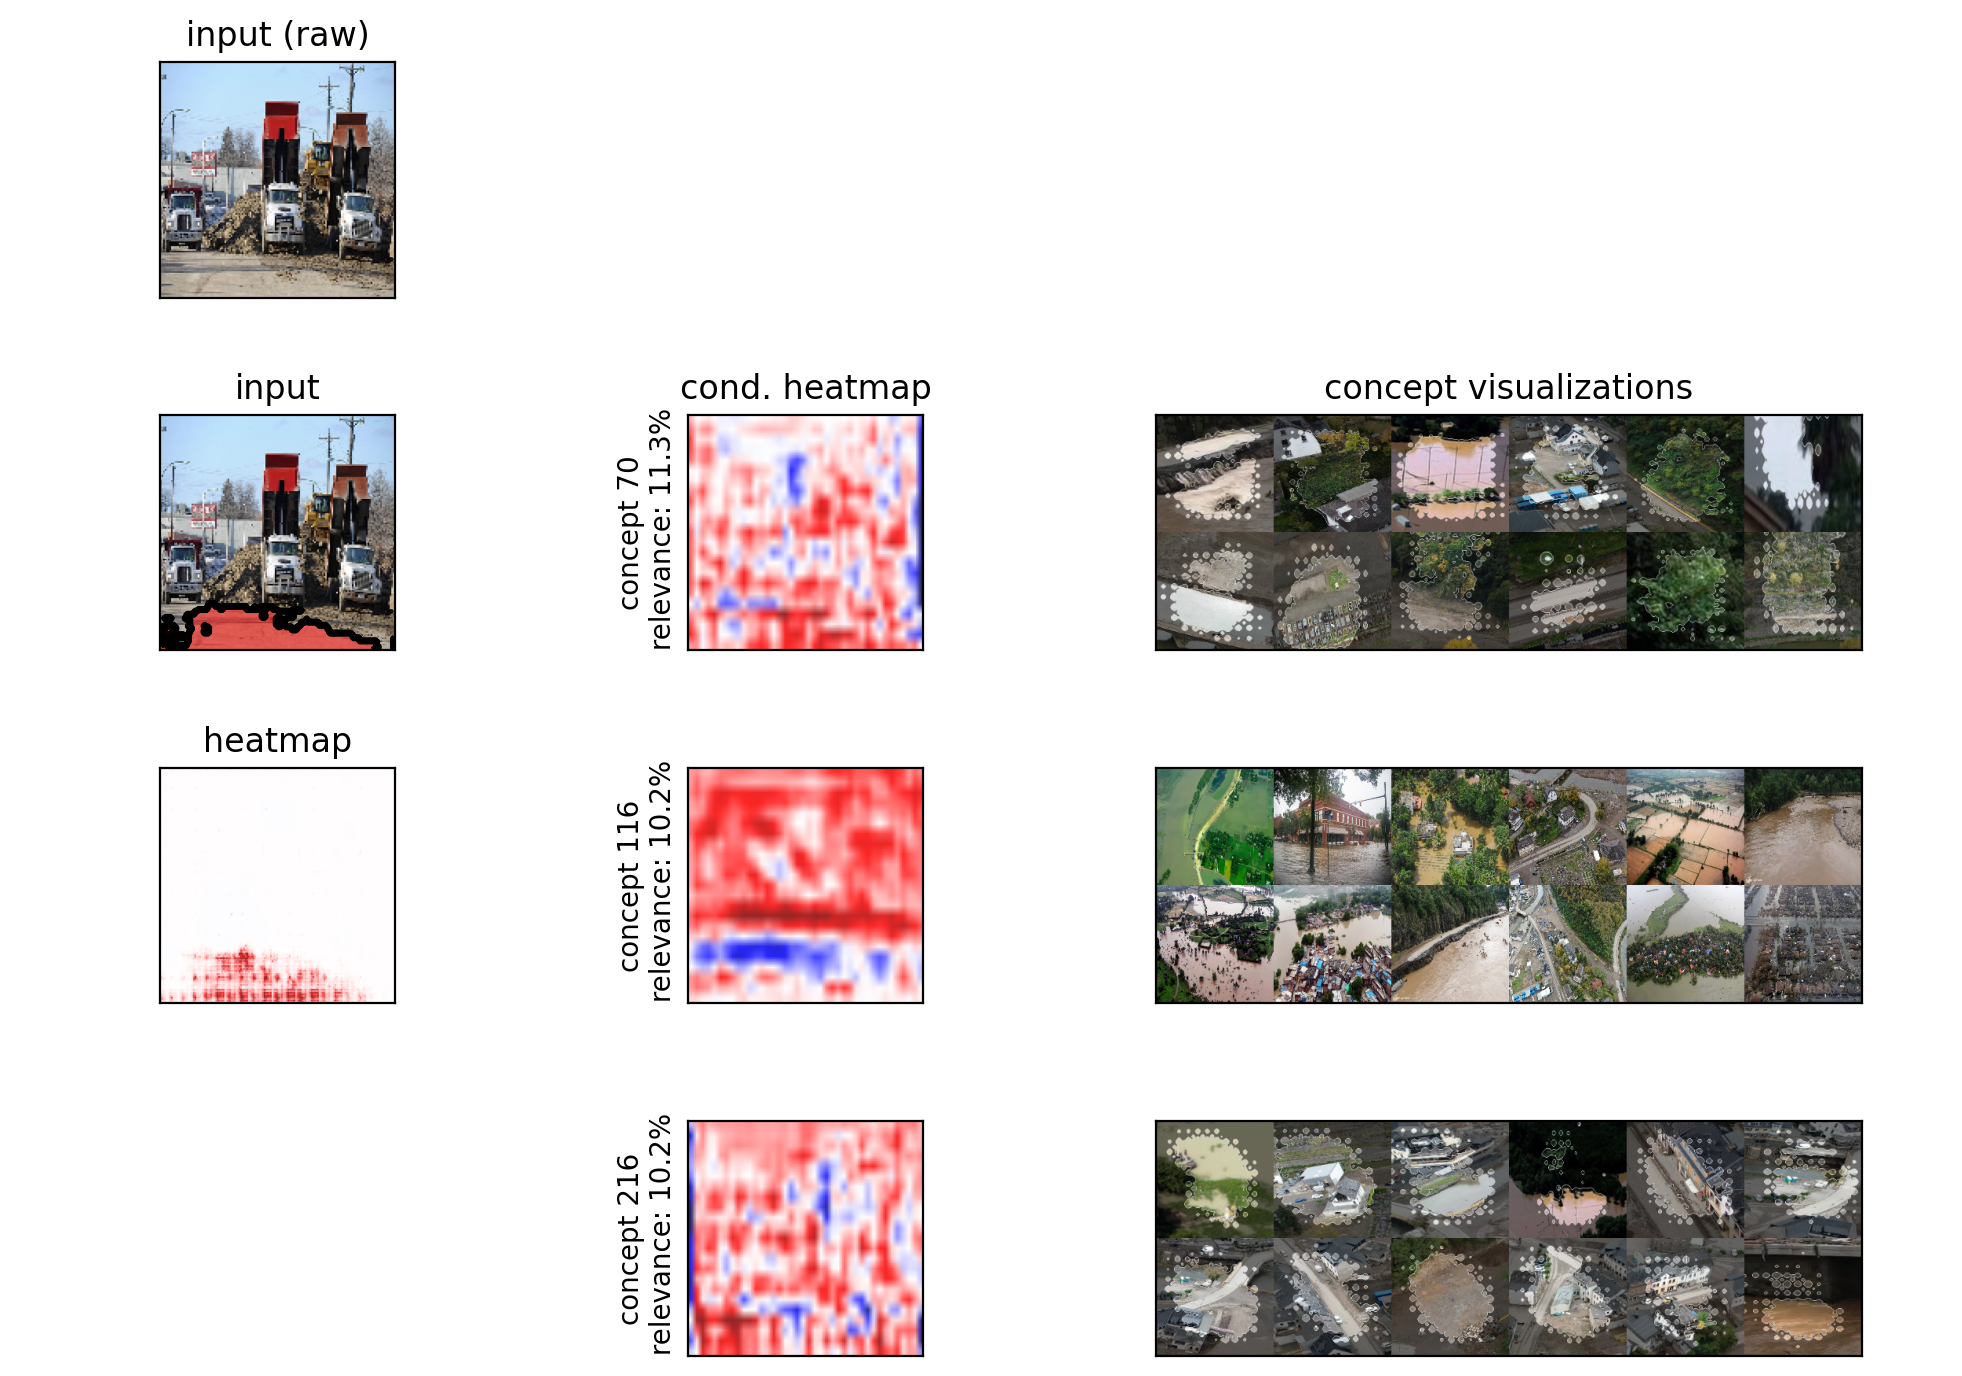

Done plotting.


In [3]:
#cell 7

# Setting up main parameters
from src.datasets.flood_datase_crp import FloodDataset 

class_id = 1
sample_id = 67
n_concepts = 3
n_refimgs = 12
layer = "layer4.2.conv1"
# layer = "layer1.1.conv1"
mode = "activation"
prediction_num = 0

root_dir = "/home/heydari/FHHI-XAI/data/BRK-data/"
dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded dataset:', type(dataset))
print('len(dataset) =', len(dataset))


# if failing, try to restart the notebook and do not run analysis again, go directly to plotting
plot_explanations(model_name, model, dataset, sample_id, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir=output_dir)

In [3]:
#cell 8

import os
from torch.utils.data import DataLoader
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names
from datetime import datetime
from tqdm import tqdm
from torchvision.utils import make_grid

# === CRP & Zennit ===
import zennit.image as zimage
from crp.image import imgify
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names
from crp.concepts import ChannelConcept


In [ ]:
#cell 9

from collections import defaultdict

dataloader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=8)
cc = ChannelConcept()
output_dir_crp = "../examples/output/crp/CRP-BRK-NEW/"

layer_names = get_layer_names(model, [torch.nn.Conv2d])
attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
condition = [{"y": class_id}]
fv = VISUALIZATIONS[model_name](
    attribution, dataset, layer_names,
    preprocess_fn=lambda x: x, path=output_dir_crp, max_target="max"
)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

#start = datetime.now()
activations = defaultdict(list)
attributions = defaultdict(list)

for i, (x, y) in enumerate(tqdm(dataset)):
    x = x.to(device).requires_grad_()
    attr = attribution(x.unsqueeze(0), condition, composite, record_layer=layer_names)

    for ln in layer_names:
        if ln not in attr.activations or ln not in attr.relevances:
            continue

        acts = attr.activations[ln].amax((-2, -1)).detach().cpu()
        rels = cc.attribute(attr.relevances[ln], abs_norm=True).detach().cpu()
        acts = torch.nan_to_num(acts, nan=0.0, posinf=0.0, neginf=0.0)
        rels = torch.nan_to_num(rels, nan=0.0, posinf=0.0, neginf=0.0)

        activations[ln].append(acts)
        attributions[ln].append(rels)

for ln, act_list in activations.items():
    if not attributions[ln]:
        continue

    act_tensor = torch.nan_to_num(torch.cat(act_list), nan=0.0, posinf=0.0, neginf=0.0)
    rel_tensor = torch.nan_to_num(torch.cat(attributions[ln]), nan=0.0, posinf=0.0, neginf=0.0)

    folder = os.path.join("/home/heydari/FHHI-XAI/examples/output/pcx/PCX-BRK-NEW/", ln)
    os.makedirs(folder, exist_ok=True)
    np.save(os.path.join(folder, "activations.npy"), act_tensor.numpy())
    np.save(os.path.join(folder, "attributions.npy"), rel_tensor.numpy())

#end = datetime.now()
#print(f"elapsed: {end - start}")


DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


Loaded BRK dataset: <class 'src.datasets.flood_datase_crp.FloodDataset'>
len(dataset) = 1322
[plot_pcx_explanations] starting
[plot_pcx_explanations] sample_id=67 img.shape=(3, 720, 1280)
[plot_one_image_pcx_explanation] device=cpu, layer=layer2.1.conv1
[attr] building attribution/composite/visualization
[attr] layer_map size=79
[data] x.shape=(1, 3, 720, 1280)
[attr] computing base attribution
[attr] base heatmap computed
[mask] building predicted mask
[mask] reverse_augmentation available, target size=(720, 1280)
[mask] resized mask -> (720, 1280)
[concepts] computing channel relevances
[concepts] channel_rels shape=(1, 64)
[concepts] topk_ind=[6, 33, 41] topk_rel=[0.1289999932050705, 0.032999999821186066, 0.029999999329447746]
[attr] computing conditional heatmaps
[refs] computing/loading reference images
[get_ref_images] start; layer=layer2.1.conv1, n_ref=12, cache=../examples/new-ref-img-BRK/layer2.1.conv1.h5
[get_ref_images] cache exists -> reading known keys
[get_ref_images] loa

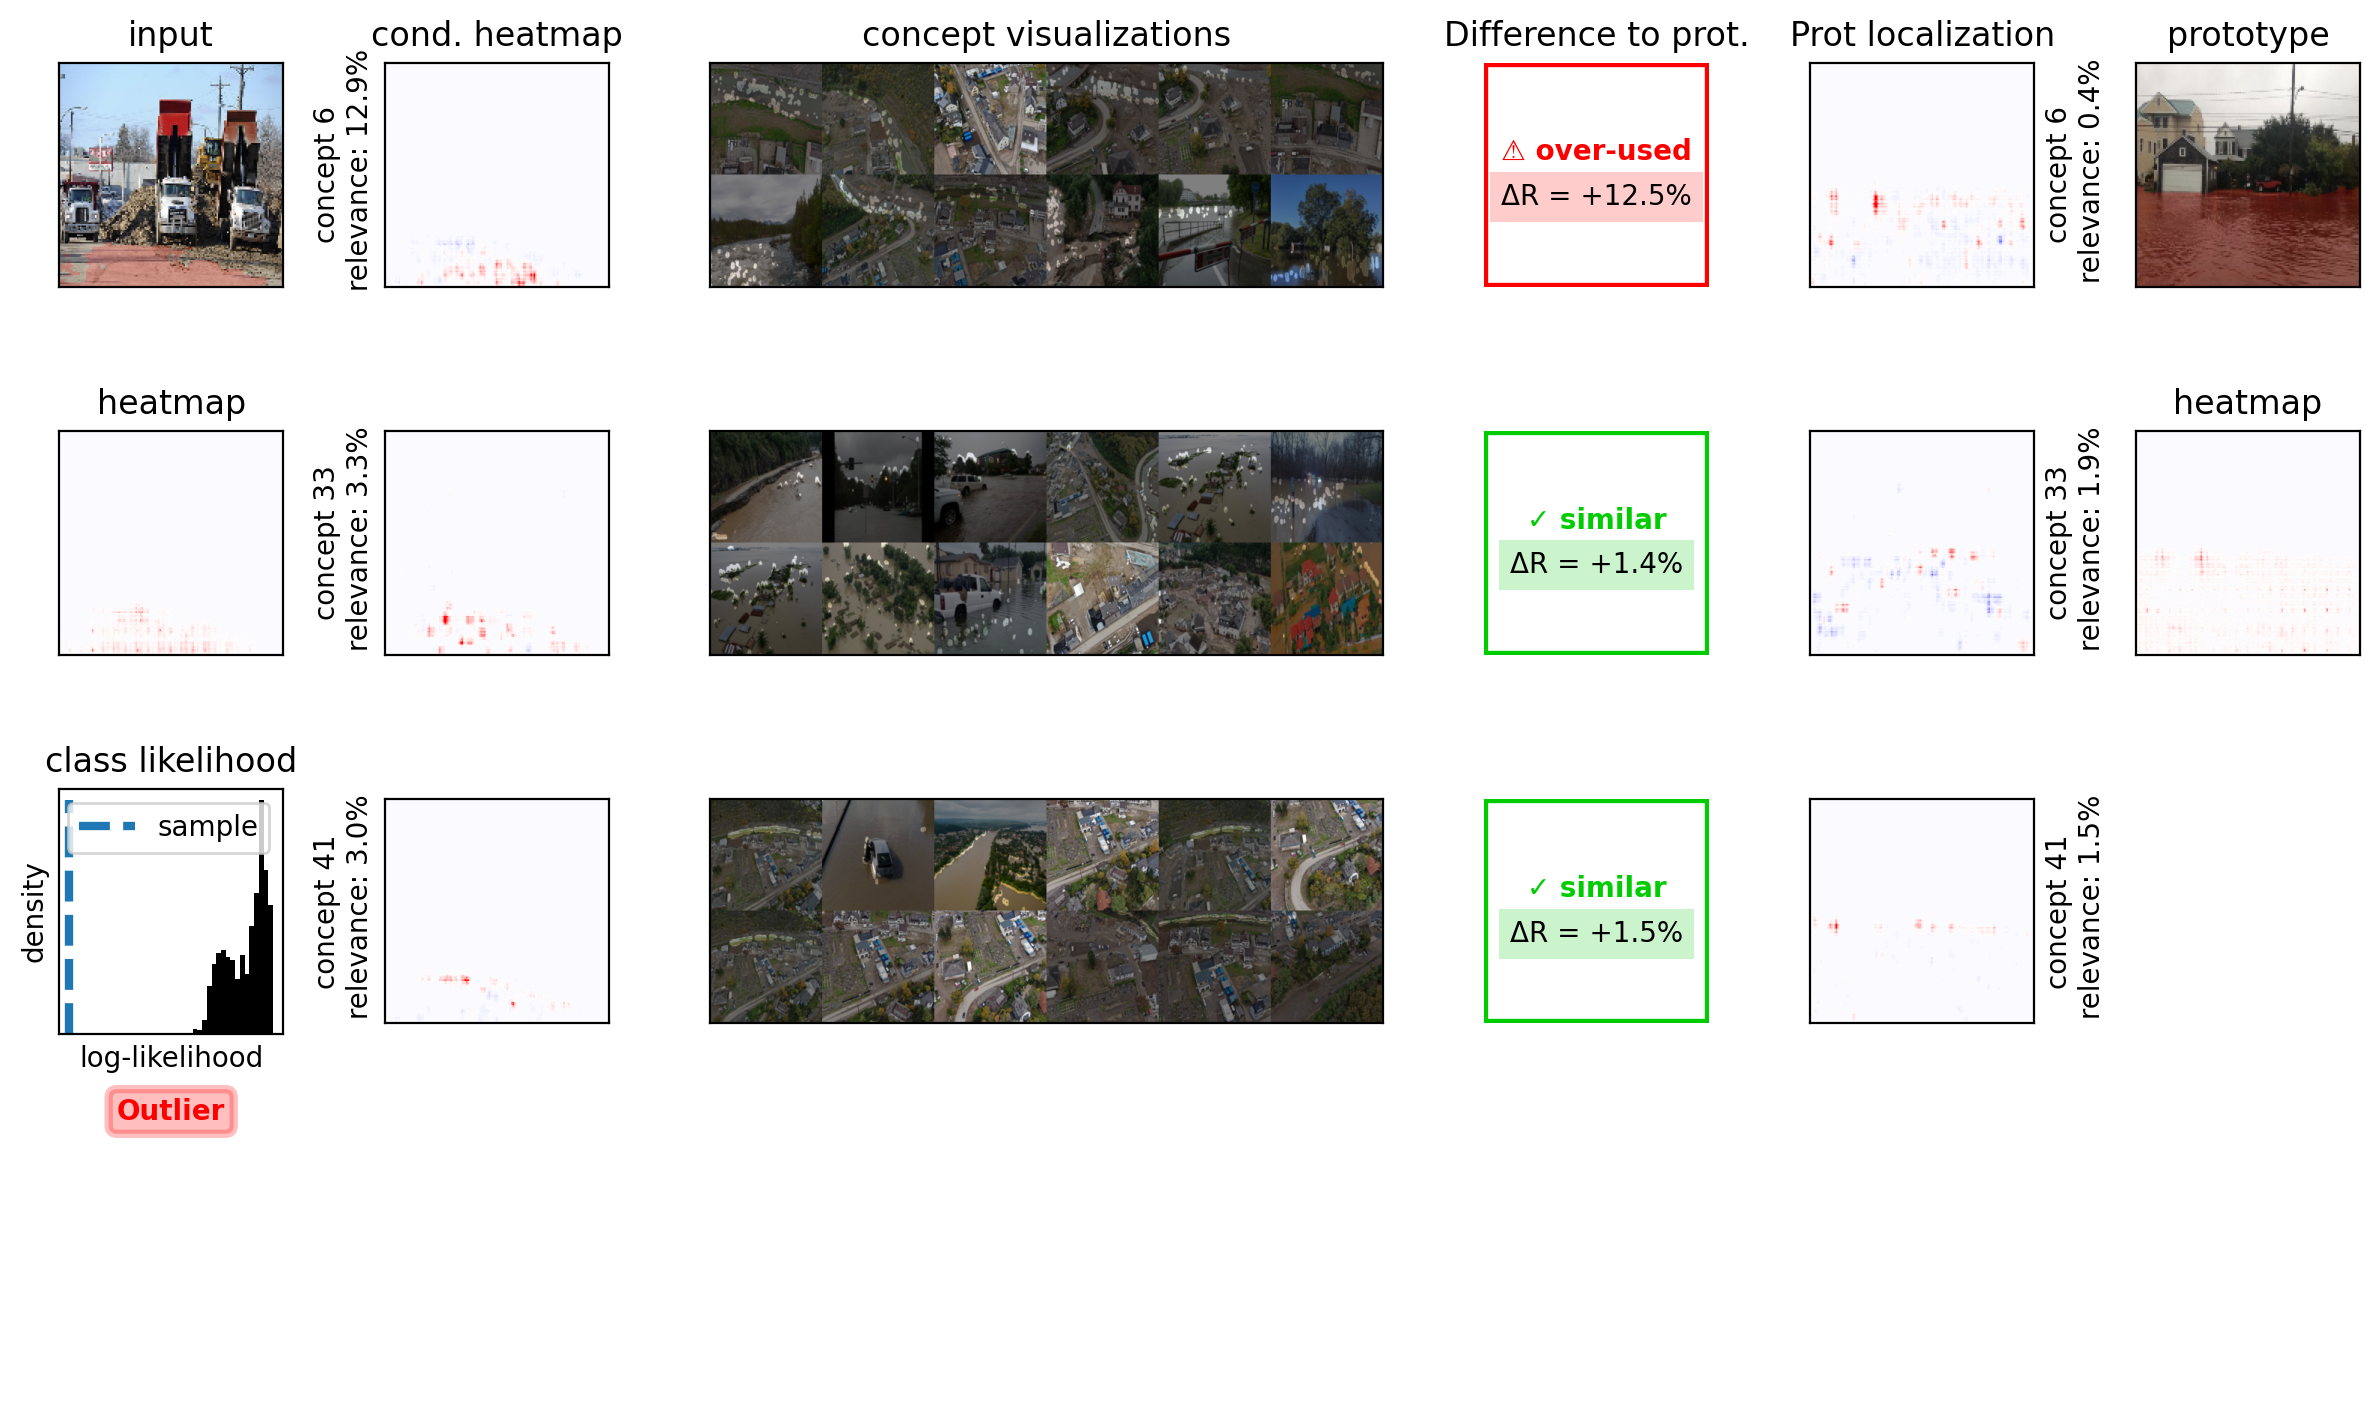

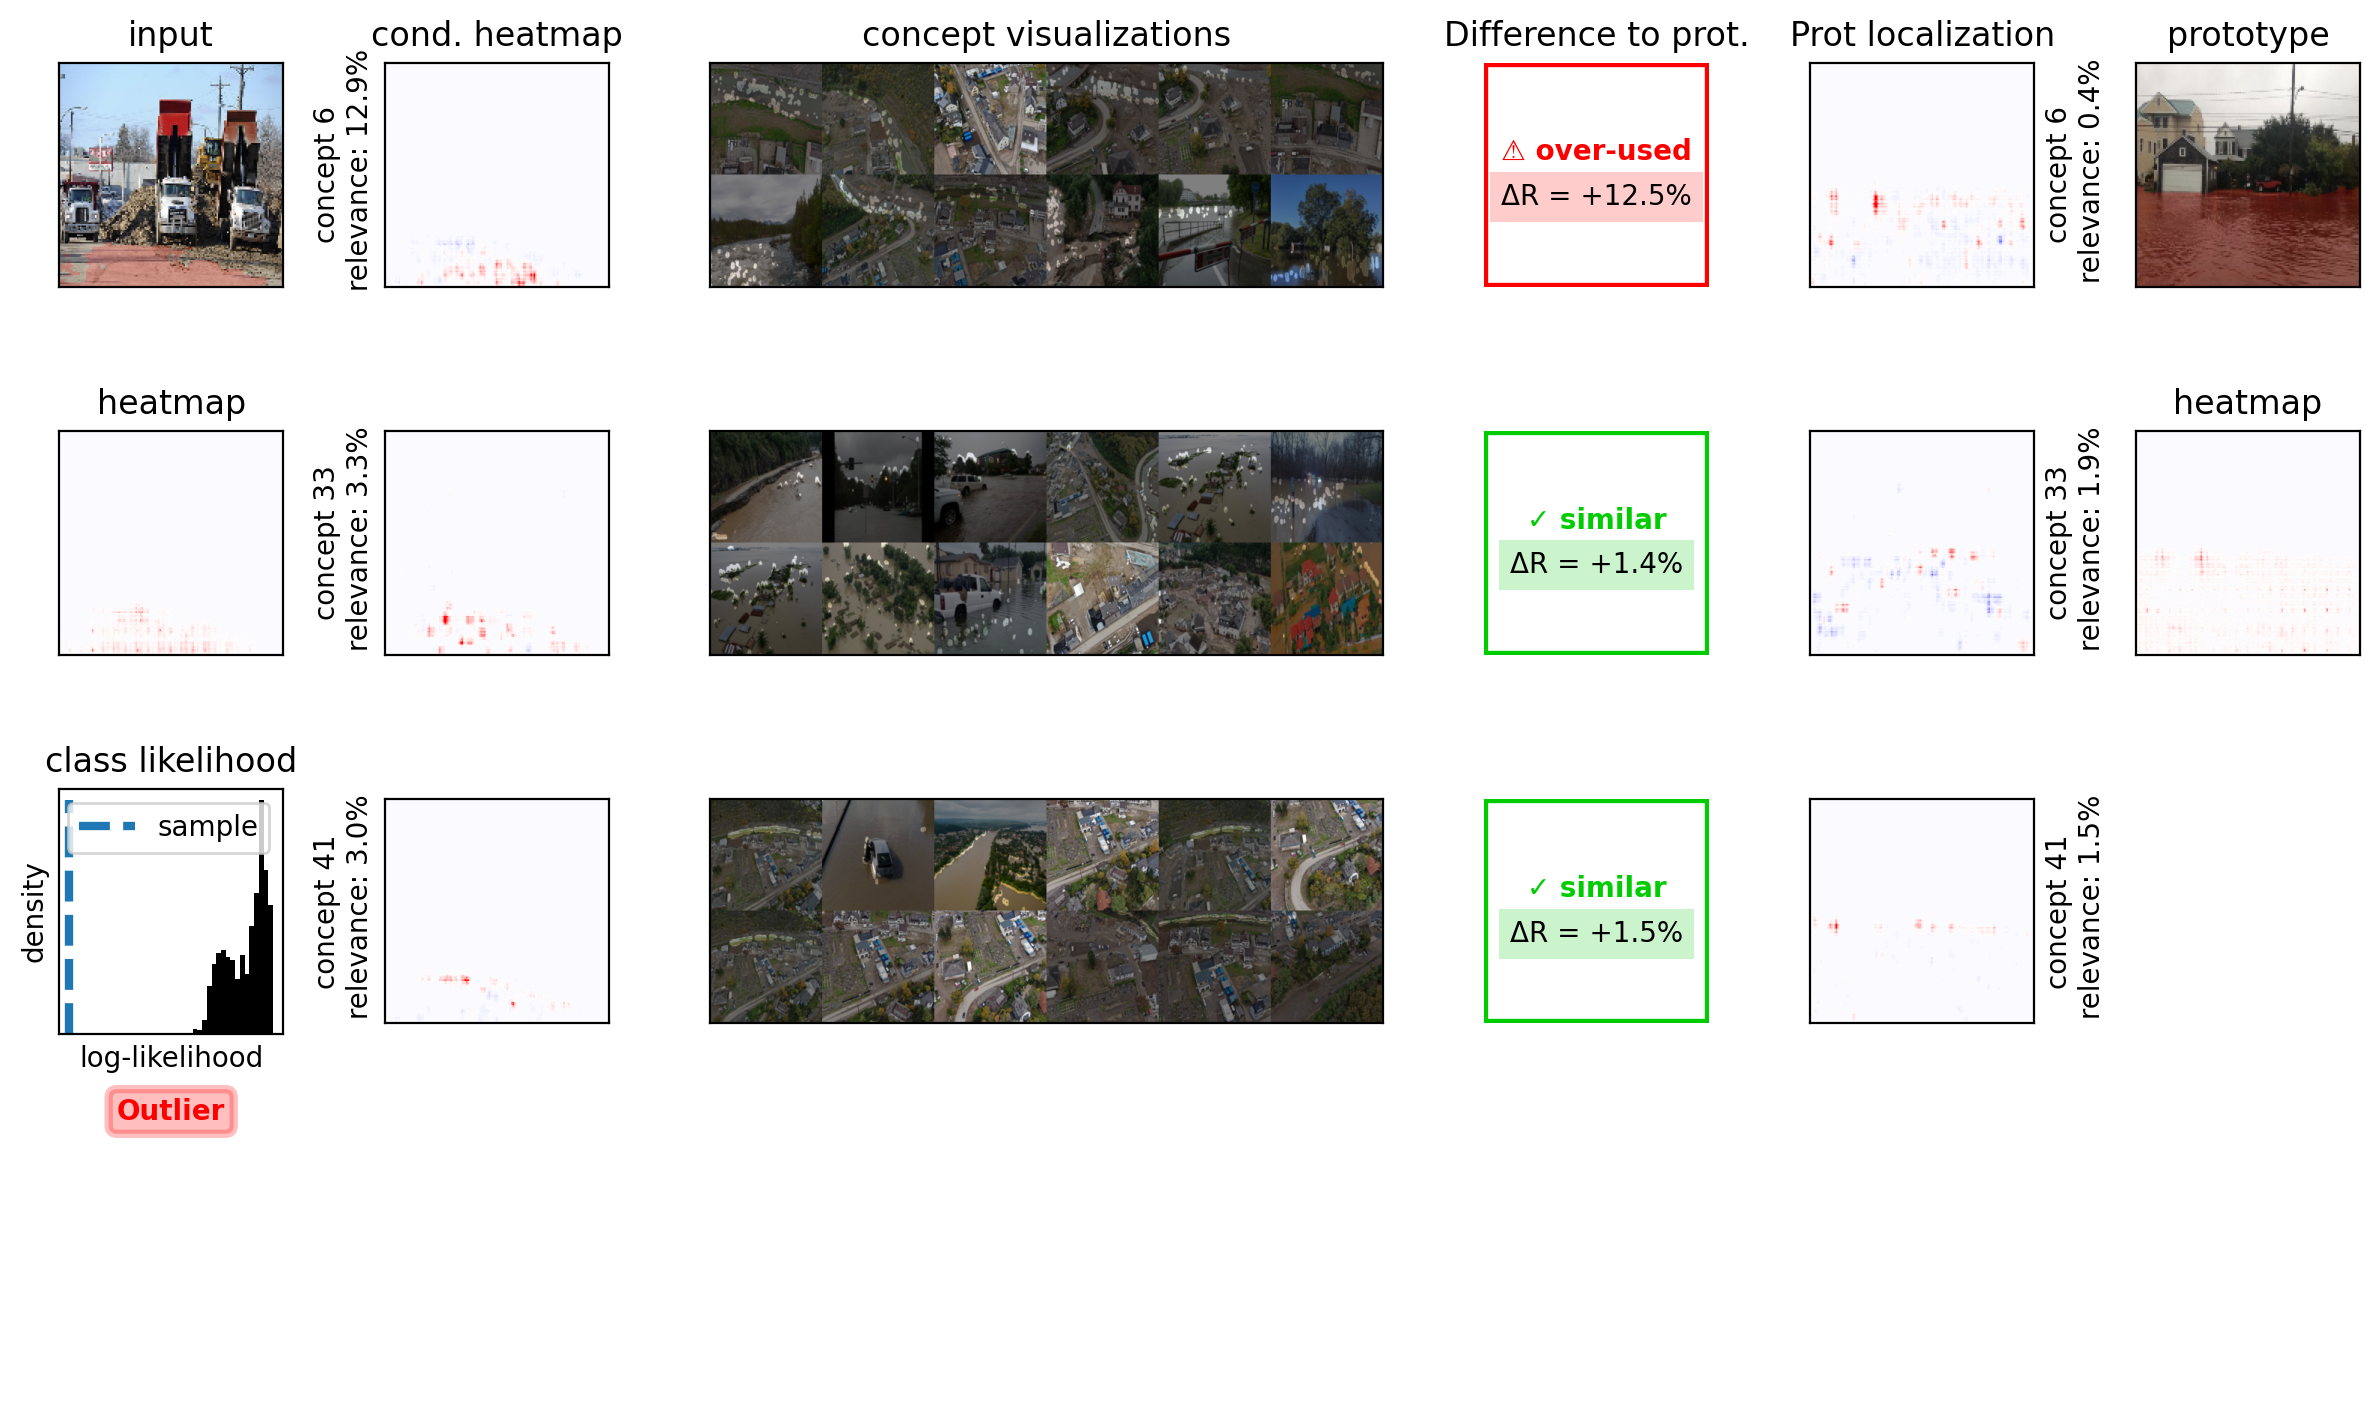

In [4]:
#cell 10 - Analyze BRK dataset with CRP/PCX
from src.datasets.flood_datase_crp import FloodDataset 
import os
from src.plot_pcx_pidnet_new import plot_pcx_explanations

# Load BRK dataset (same as the reference dataset)
root_dir = "../data/BRK-data/"
brk_dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded BRK dataset:', type(brk_dataset))
print(f'len(dataset) = {len(brk_dataset)}')

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Use BRK output paths
output_dir_crp = "../examples/output/crp/CRP-BRK-NEW/"
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"

# Validate sample_id before processing
sample_id = 67  # Change this to any valid sample ID
layer_name = 'layer2.1.conv1'

    
plot_pcx_explanations(
        "pidnet",
        model.to(device),
        brk_dataset,
        sample_id=sample_id,
        layer_name=layer_name,
        n_concepts=3,
        n_refimgs=12,
        num_prototypes=12,
        ref_imgs_path="../examples/new-ref-img-BRK",
        output_dir_crp=output_dir_crp,
        output_dir_pcx=output_dir_pcx,
)

In [5]:
# Find ALL outliers in BRK dataset
import numpy as np
from sklearn.mixture import GaussianMixture
import os

print("="*90)
print("BRK DATASET - OUTLIER DETECTION")
print("="*90)

layer_name = "layer4.1.conv1"
num_prototypes = 5
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"

# Load attributions
attr_path = os.path.join(output_dir_pcx, layer_name, "attributions.npy")
if not os.path.exists(attr_path):
    print(f"\n✗ Attributions NOT found at: {attr_path}")
    print(f"Please run cell 10 first to generate CRP/PCX explanations")
else:
    print(f"\n✓ Loading attributions from: {attr_path}")
    
    attributions_np = np.load(attr_path)
    print(f"Attributions shape: {attributions_np.shape}")
    
    # Track original indices through cleaning
    original_indices = np.arange(len(attributions_np))
    
    # EXACT same cleaning as plot_pcx_explanations
    finite_mask = np.isfinite(attributions_np).all(axis=1)
    if not finite_mask.all():
        bad = int((~finite_mask).sum())
        print(f"[gmm] WARNING: dropping {bad} rows with NaN/Inf values")
        attributions_np = attributions_np[finite_mask]
        original_indices = original_indices[finite_mask]
    
    attributions_np = np.nan_to_num(attributions_np, nan=0.0, posinf=0.0, neginf=0.0)
    
    nonzero_mask = ~(np.isclose(attributions_np.std(axis=1), 0.0) & np.isclose(attributions_np.mean(axis=1), 0.0))
    if not nonzero_mask.all():
        dropped = int((~nonzero_mask).sum())
        print(f"[gmm] INFO: dropping {dropped} constant rows")
        attributions_np = attributions_np[nonzero_mask]
        original_indices = original_indices[nonzero_mask]
    
    print(f"After cleaning: {attributions_np.shape[0]} samples\n")
    
    # Fit GMM with num_prototypes
    gmm = GaussianMixture(n_components=num_prototypes, reg_covar=1e-5, random_state=0).fit(attributions_np)
    scores = gmm.score_samples(attributions_np)
    
    # Calculate p1 threshold
    p1 = np.percentile(scores, 1)
    print(f"p1 threshold (1st percentile): {p1:.4f}")
    
    # Find outliers
    outlier_mask = scores < p1
    outlier_indices_cleaned = np.where(outlier_mask)[0]
    outlier_scores = scores[outlier_mask]
    
    # Sort by score (lowest first)
    sort_idx = np.argsort(outlier_scores)
    outlier_indices_cleaned = outlier_indices_cleaned[sort_idx]
    outlier_scores = outlier_scores[sort_idx]
    outlier_indices_original = original_indices[outlier_indices_cleaned]
    
    print(f"Total outliers found: {len(outlier_indices_cleaned)}\n")
    
    print(f"{'='*100}")
    print(f"BRK OUTLIER LIST (sorted by score, lowest first)")
    print(f"{'='*100}")
    print(f"{'Cleaned Idx':<15} {'Original Idx':<15} {'Score':<15} {'Filename'}")
    print(f"{'-'*100}")
    
    for cleaned_idx, orig_idx, score in zip(
        outlier_indices_cleaned[:50], 
        outlier_indices_original[:50], 
        outlier_scores[:50]
    ):
        filename = os.path.basename(str(brk_dataset.files[int(orig_idx)]["img"]))
        print(f"{int(cleaned_idx):<15} {int(orig_idx):<15} {float(score):<15.4f} {filename}")
    
    print(f"\nAll Cleaned indices: {outlier_indices_cleaned.tolist()}")
    print(f"All Original indices: {outlier_indices_original.tolist()}")

BRK DATASET - OUTLIER DETECTION

✓ Loading attributions from: ../examples/output/pcx/PCX-BRK-NEW/layer4.1.conv1/attributions.npy
Attributions shape: (1321, 256)
[gmm] INFO: dropping 148 constant rows
After cleaning: 1173 samples



KeyboardInterrupt: 

In [9]:
# Check a specific sample with proper index mapping
import numpy as np
from sklearn.mixture import GaussianMixture

layer_name = "layer4.1.conv1"
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"
sample_id_check = 80  # ID from the cleaned/filtered dataset

# Load attributions
attr_path = f"{output_dir_pcx}/{layer_name}/attributions.npy"
X = np.load(attr_path)
print(f"Original dataset size: {X.shape[0]}")

# Track indices through cleaning
original_indices = np.arange(len(X))

# Clean data (same as outlier detection)
finite_mask = np.isfinite(X).all(axis=1)
X_finite = X[finite_mask]
original_indices_finite = original_indices[finite_mask]

X_clean = np.nan_to_num(X_finite, nan=0.0, posinf=0.0, neginf=0.0)

nonzero_mask = ~(np.isclose(X_clean.std(axis=1), 0.0) & np.isclose(X_clean.mean(axis=1), 0.0))
X_clean = X_clean[nonzero_mask]
original_indices_clean = original_indices_finite[nonzero_mask]

print(f"Cleaned dataset size: {X_clean.shape[0]}")

# Fit GMM
gmm = GaussianMixture(n_components=7, reg_covar=1e-5, random_state=0).fit(X_clean)
scores = gmm.score_samples(X_clean)
p1 = np.percentile(scores, 1)

# Check the sample
if sample_id_check < len(X_clean):
    score_sample = scores[sample_id_check]
    original_id = original_indices_clean[sample_id_check]
    label = "Outlier" if score_sample < p1 else "Ordinary"
    
    print(f"\n{'='*60}")
    print(f"Cleaned index: {sample_id_check}")
    print(f"Original index: {int(original_id)}")
    print(f"Score: {score_sample:.4f}")
    print(f"p1 threshold: {p1:.4f}")
    print(f"Label: {label}")
    print(f"{'='*60}")
else:
    print(f"❌ ERROR: index {sample_id_check} out of range in cleaned data (max={len(X_clean)-1})")

Original dataset size: 1321
Cleaned dataset size: 1173

Cleaned index: 80
Original index: 98
Score: 1176.3907
p1 threshold: 1177.9482
Label: Outlier


In [33]:
# Find outliers using EXACT same GMM as plot_pcx_explanations
import numpy as np
from sklearn.mixture import GaussianMixture

layer_name = "layer2.1.conv1"
num_prototypes = 5  # MUST match what you pass to plot_pcx_explanations!
n_outliers_display = 20

# Load attributions
attr_path = f"{output_dir_pcx}/{layer_name}/attributions.npy"
attributions_np = np.load(attr_path)
print(f"Original dataset size: {attributions_np.shape}")

# Track original indices through cleaning
original_indices = np.arange(len(attributions_np))

# EXACT same cleaning as plot_pcx_explanations (lines 258-277)
finite_mask = np.isfinite(attributions_np).all(axis=1)
if not finite_mask.all():
    bad = int((~finite_mask).sum())
    print(f"[gmm] WARNING: dropping {bad} rows with NaN/Inf values")
    attributions_np = attributions_np[finite_mask]
    original_indices = original_indices[finite_mask]

attributions_np = np.nan_to_num(attributions_np, nan=0.0, posinf=0.0, neginf=0.0)

nonzero_mask = ~(np.isclose(attributions_np.std(axis=1), 0.0) & np.isclose(attributions_np.mean(axis=1), 0.0))
if not nonzero_mask.all():
    dropped = int((~nonzero_mask).sum())
    print(f"[gmm] INFO: dropping {dropped} constant rows")
    attributions_np = attributions_np[nonzero_mask]
    original_indices = original_indices[nonzero_mask]

print(f"Cleaned dataset size: {attributions_np.shape[0]}\n")

# EXACT same GMM fitting as plot_pcx_explanations (lines 278-287)
gmm = GaussianMixture(n_components=num_prototypes, reg_covar=1e-5, random_state=0).fit(attributions_np)
scores = gmm.score_samples(attributions_np)

# Calculate p1 threshold (same as in visualization)
p1 = np.percentile(scores, 1)
print(f"p1 threshold (1st percentile): {p1:.4f}")

# Find outliers
outlier_mask = scores < p1
outlier_indices_cleaned = np.where(outlier_mask)[0]
outlier_scores = scores[outlier_mask]

# Sort by score (lowest first)
sort_idx = np.argsort(outlier_scores)
outlier_indices_cleaned = outlier_indices_cleaned[sort_idx]
outlier_scores = outlier_scores[sort_idx]
outlier_indices_original = original_indices[outlier_indices_cleaned]

print(f"Total outliers found: {len(outlier_indices_cleaned)}\n")

print(f"{'='*90}")
print(f"OUTLIER LIST (sorted by score, lowest first)")
print(f"{'='*90}")
print(f"{'Cleaned Idx':<15} {'Original Idx':<15} {'Score':<15}")
print(f"{'-'*90}")
for i, (cleaned_idx, orig_idx, score) in enumerate(zip(
    outlier_indices_cleaned[:n_outliers_display], 
    outlier_indices_original[:n_outliers_display], 
    outlier_scores[:n_outliers_display]
)):
    print(f"{int(cleaned_idx):<15} {int(orig_idx):<15} {float(score):<15.4f}")

print(f"\nCleaned indices: {outlier_indices_cleaned[:n_outliers_display].tolist()}")
print(f"Original indices: {outlier_indices_original[:n_outliers_display].tolist()}")

Original dataset size: (1321, 64)
[gmm] INFO: dropping 148 constant rows
Cleaned dataset size: 1173

p1 threshold (1st percentile): 167.4953
Total outliers found: 12

OUTLIER LIST (sorted by score, lowest first)
Cleaned Idx     Original Idx    Score          
------------------------------------------------------------------------------------------
284             342             115.9989       
833             925             134.3486       
326             384             139.1993       
892             984             146.8413       
464             533             151.3597       
225             279             155.2166       
272             330             156.8338       
221             275             159.1168       
695             773             163.1074       
513             585             164.9659       
461             529             166.6686       
259             315             167.3224       

Cleaned indices: [284, 833, 326, 892, 464, 225, 272, 221, 695, 513, 461,

In [22]:
# Find sample number for a specific image in the dataset
import os

# The image file you're looking for
target_image = "image_10571.jpg"

# Search through the dataset's files list
found_indices = []
for idx, file_dict in enumerate(dataset.files):
    img_path = str(file_dict["img"])
    filename = os.path.basename(img_path)
    
    if filename == target_image:
        found_indices.append(idx)
        print(f"✓ Found: {target_image}")
        print(f"  Sample index: {idx}")
        print(f"  Full path: {img_path}")
        print(f"  Label path: {file_dict['label']}")

if not found_indices:
    print(f"✗ Image '{target_image}' not found in dataset")
    print(f"\nAvailable images (first 20):")
    for idx, file_dict in enumerate(dataset.files[:20]):
        filename = os.path.basename(str(file_dict["img"]))
        print(f"  {idx}: {filename}")
else:
    print(f"\nSample number(s) for '{target_image}': {found_indices}")

✓ Found: image_10571.jpg
  Sample index: 67
  Full path: /home/heydari/FHHI-XAI/data/BRK-data/RGB/train/JPEG/image_10571.jpg
  Label path: /home/heydari/FHHI-XAI/data/BRK-data/annotations/train/JPEG/image_10571Ids.jpg

Sample number(s) for 'image_10571.jpg': [67]


In [21]:
# Load Mantoudi dataset and compute attributions + find outliers
import os
import numpy as np
import torch
from sklearn.mixture import GaussianMixture
from src.datasets.flood_test import FloodDataset
from src.plot_pcx_pidnet_new import plot_pcx_explanations

# Load Mantoudi dataset
print("="*80)
print("MANTOUDI FLOOD SEGMENTATION DATASET")
print("="*80)

mantoudi_root_dir = "../data/Mantoudi/flood_segmentation/"
mantoudi_dataset = FloodDataset(root_dir=mantoudi_root_dir, transform=transform)
print(f"Dataset loaded: {len(mantoudi_dataset)} samples\n")

# Show first few samples
print("First 10 samples in Mantoudi dataset:")
for idx in range(min(10, len(mantoudi_dataset))):
    img_path = str(mantoudi_dataset.files[idx]["img"])
    filename = os.path.basename(img_path)
    print(f"  {idx}: {filename}")

# Parameters for analysis
layer_name = "layer4.1.conv1"
num_prototypes = 5
output_dir_mantoudi_pcx = "../examples/output/pcx/PCX-Mantoudi-NEW/"

# Check if attributions exist
attr_path = os.path.join(output_dir_mantoudi_pcx, layer_name, "attributions.npy")
if os.path.exists(attr_path):
    print(f"\n✓ Attributions found at: {attr_path}")
    
    # Load and analyze
    attributions_np = np.load(attr_path)
    print(f"Attributions shape: {attributions_np.shape}")
    
    # Track original indices
    original_indices = np.arange(len(attributions_np))
    
    # Clean data
    finite_mask = np.isfinite(attributions_np).all(axis=1)
    if not finite_mask.all():
        bad = int((~finite_mask).sum())
        print(f"[gmm] Dropping {bad} rows with NaN/Inf values")
        attributions_np = attributions_np[finite_mask]
        original_indices = original_indices[finite_mask]
    
    attributions_np = np.nan_to_num(attributions_np, nan=0.0, posinf=0.0, neginf=0.0)
    
    nonzero_mask = ~(np.isclose(attributions_np.std(axis=1), 0.0) & np.isclose(attributions_np.mean(axis=1), 0.0))
    if not nonzero_mask.all():
        dropped = int((~nonzero_mask).sum())
        print(f"[gmm] Dropping {dropped} constant rows")
        attributions_np = attributions_np[nonzero_mask]
        original_indices = original_indices[nonzero_mask]
    
    print(f"After cleaning: {attributions_np.shape[0]} samples\n")
    
    # Fit GMM
    gmm = GaussianMixture(n_components=num_prototypes, reg_covar=1e-5, random_state=0).fit(attributions_np)
    scores = gmm.score_samples(attributions_np)
    
    # Find outliers
    p1 = np.percentile(scores, 1)
    print(f"p1 threshold (1st percentile): {p1:.4f}")
    
    outlier_mask = scores < p1
    outlier_indices_cleaned = np.where(outlier_mask)[0]
    outlier_scores = scores[outlier_mask]
    
    # Sort by score
    sort_idx = np.argsort(outlier_scores)
    outlier_indices_cleaned = outlier_indices_cleaned[sort_idx]
    outlier_scores = outlier_scores[sort_idx]
    outlier_indices_original = original_indices[outlier_indices_cleaned]
    
    print(f"Total outliers found: {len(outlier_indices_cleaned)}\n")
    
    print(f"{'='*90}")
    print(f"MANTOUDI OUTLIER LIST (sorted by score, lowest first)")
    print(f"{'='*90}")
    print(f"{'Cleaned Idx':<15} {'Original Idx':<15} {'Score':<15} {'Filename'}")
    print(f"{'-'*90}")
    for cleaned_idx, orig_idx, score in zip(
        outlier_indices_cleaned[:30], 
        outlier_indices_original[:30], 
        outlier_scores[:30]
    ):
        filename = os.path.basename(str(mantoudi_dataset.files[int(orig_idx)]["img"]))
        print(f"{int(cleaned_idx):<15} {int(orig_idx):<15} {float(score):<15.4f} {filename}")
    
    print(f"\nCleaned indices: {outlier_indices_cleaned.tolist()}")
    print(f"Original indices: {outlier_indices_original.tolist()}")
else:
    print(f"\n✗ Attributions NOT found at: {attr_path}")
    print(f"Please run plot_pcx_explanations on Mantoudi dataset first:")
    print(f"\nExample code:")
    print(f"""
plot_pcx_explanations(
    "pidnet",
    model.to(device),
    mantoudi_dataset,
    sample_id=0,  # or any sample
    layer_name='layer4.1.conv1',
    n_concepts=5,
    n_refimgs=12,
    num_prototypes=5,
    ref_imgs_path="../examples/new-ref-img-Mantoudi",
    output_dir_crp="../examples/output/crp/CRP-Mantoudi-NEW/",
    output_dir_pcx="../examples/output/pcx/PCX-Mantoudi-NEW/",
)
    """)

MANTOUDI FLOOD SEGMENTATION DATASET
Dataset loaded: 338 samples

First 10 samples in Mantoudi dataset:
  0: DJI_20240405181254_0233.jpg
  1: DJI_20240405181256_0234.jpg
  2: DJI_20240405181929_0528.jpg
  3: DJI_20240405181930_0529.jpg
  4: DJI_20240405181931_0530.jpg
  5: DJI_20240405182210_0648.jpg
  6: DJI_20240405182212_0649.jpg
  7: DJI_20240405182213_0650.jpg
  8: DJI_20240405182214_0651.jpg
  9: DJI_20240405182216_0652.jpg

✗ Attributions NOT found at: ../examples/output/pcx/PCX-Mantoudi-NEW/layer4.1.conv1/attributions.npy
Please run plot_pcx_explanations on Mantoudi dataset first:

Example code:

plot_pcx_explanations(
    "pidnet",
    model.to(device),
    mantoudi_dataset,
    sample_id=0,  # or any sample
    layer_name='layer4.1.conv1',
    n_concepts=5,
    n_refimgs=12,
    num_prototypes=5,
    ref_imgs_path="../examples/new-ref-img-Mantoudi",
    output_dir_crp="../examples/output/crp/CRP-Mantoudi-NEW/",
    output_dir_pcx="../examples/output/pcx/PCX-Mantoudi-NEW/",
)
 

Loaded dataset: <class 'src.datasets.flood_datase_crp.FloodDataset'>
len(dataset) = 1321
[plot_pcx_explanations] starting
[plot_pcx_explanations] sample_id=925 img.shape=(3, 1280, 720)
[plot_one_image_pcx_explanation] device=cpu, layer=layer5.1.conv1
[attr] building attribution/composite/visualization
[attr] layer_map size=79
[data] x.shape=(1, 3, 1280, 720)
[attr] computing base attribution
[attr] base heatmap computed
[mask] building predicted mask
[mask] reverse_augmentation available, target size=(1280, 720)
[mask] resized mask -> (1280, 720)
[concepts] computing channel relevances
[concepts] channel_rels shape=(1, 256)
[concepts] topk_ind=[30, 163, 245] topk_rel=[0.2529999911785126, 0.23999999463558197, 0.1889999955892563]
[attr] computing conditional heatmaps
[refs] computing/loading reference images
[get_ref_images] start; layer=layer5.1.conv1, n_ref=12, cache=../examples/new-ref-img-BRK/layer5.1.conv1.h5
[get_ref_images] cache exists -> reading known keys
[get_ref_images] loade

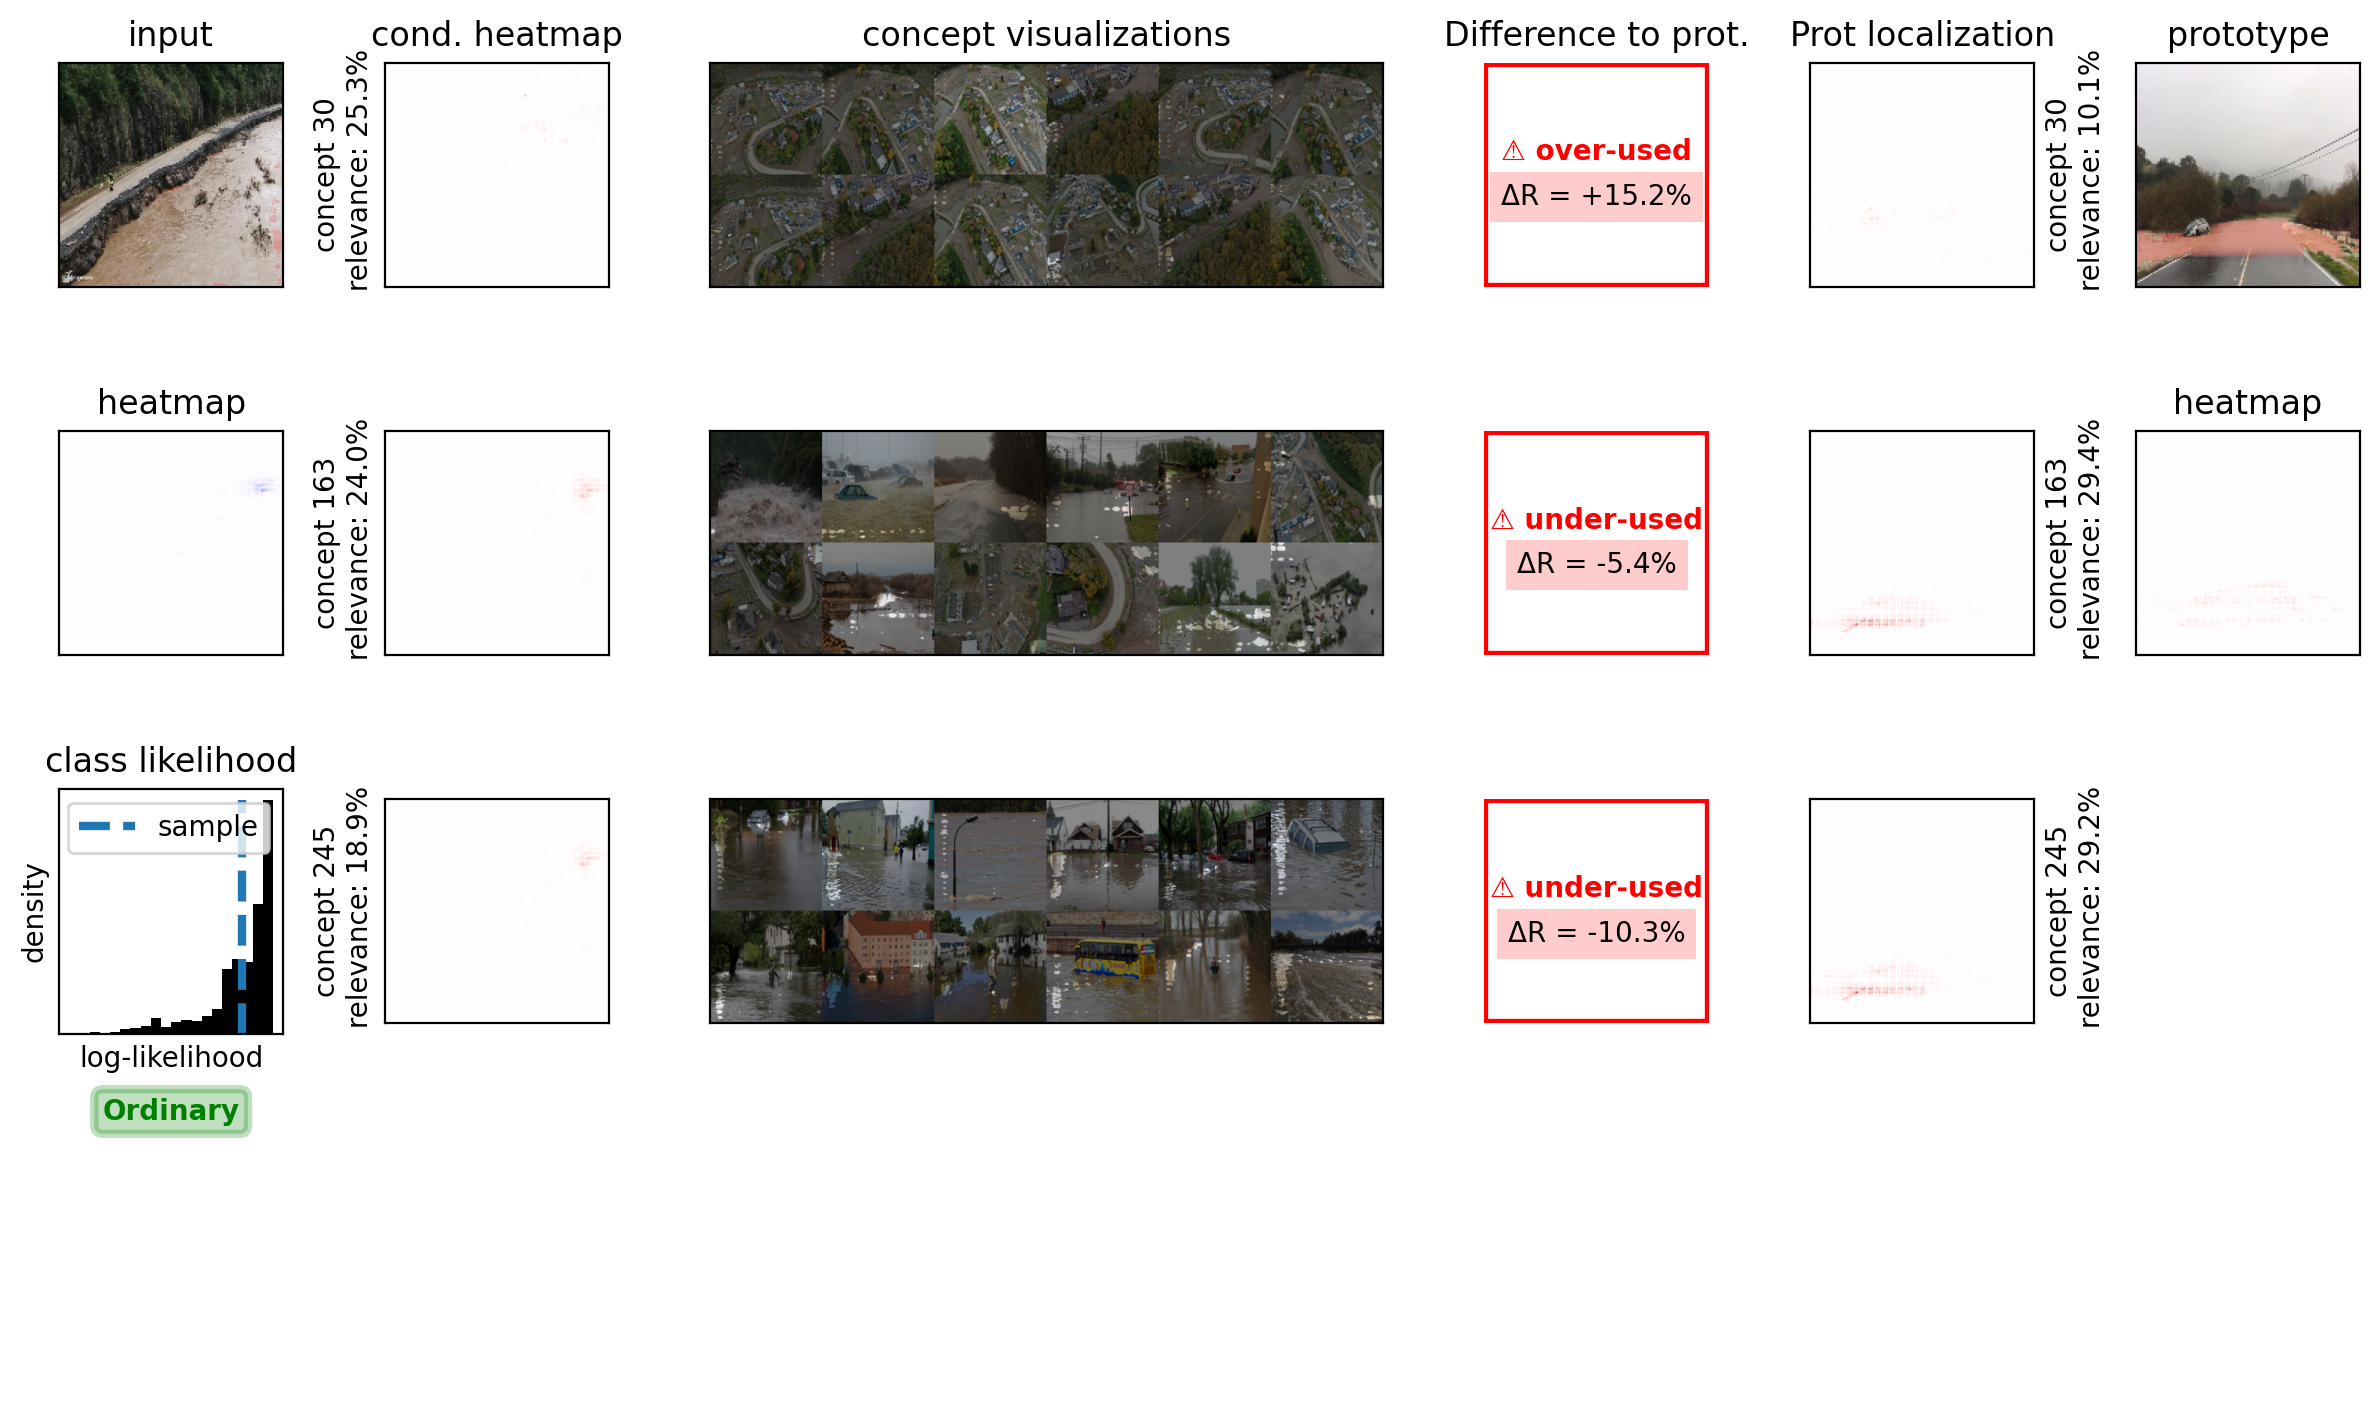

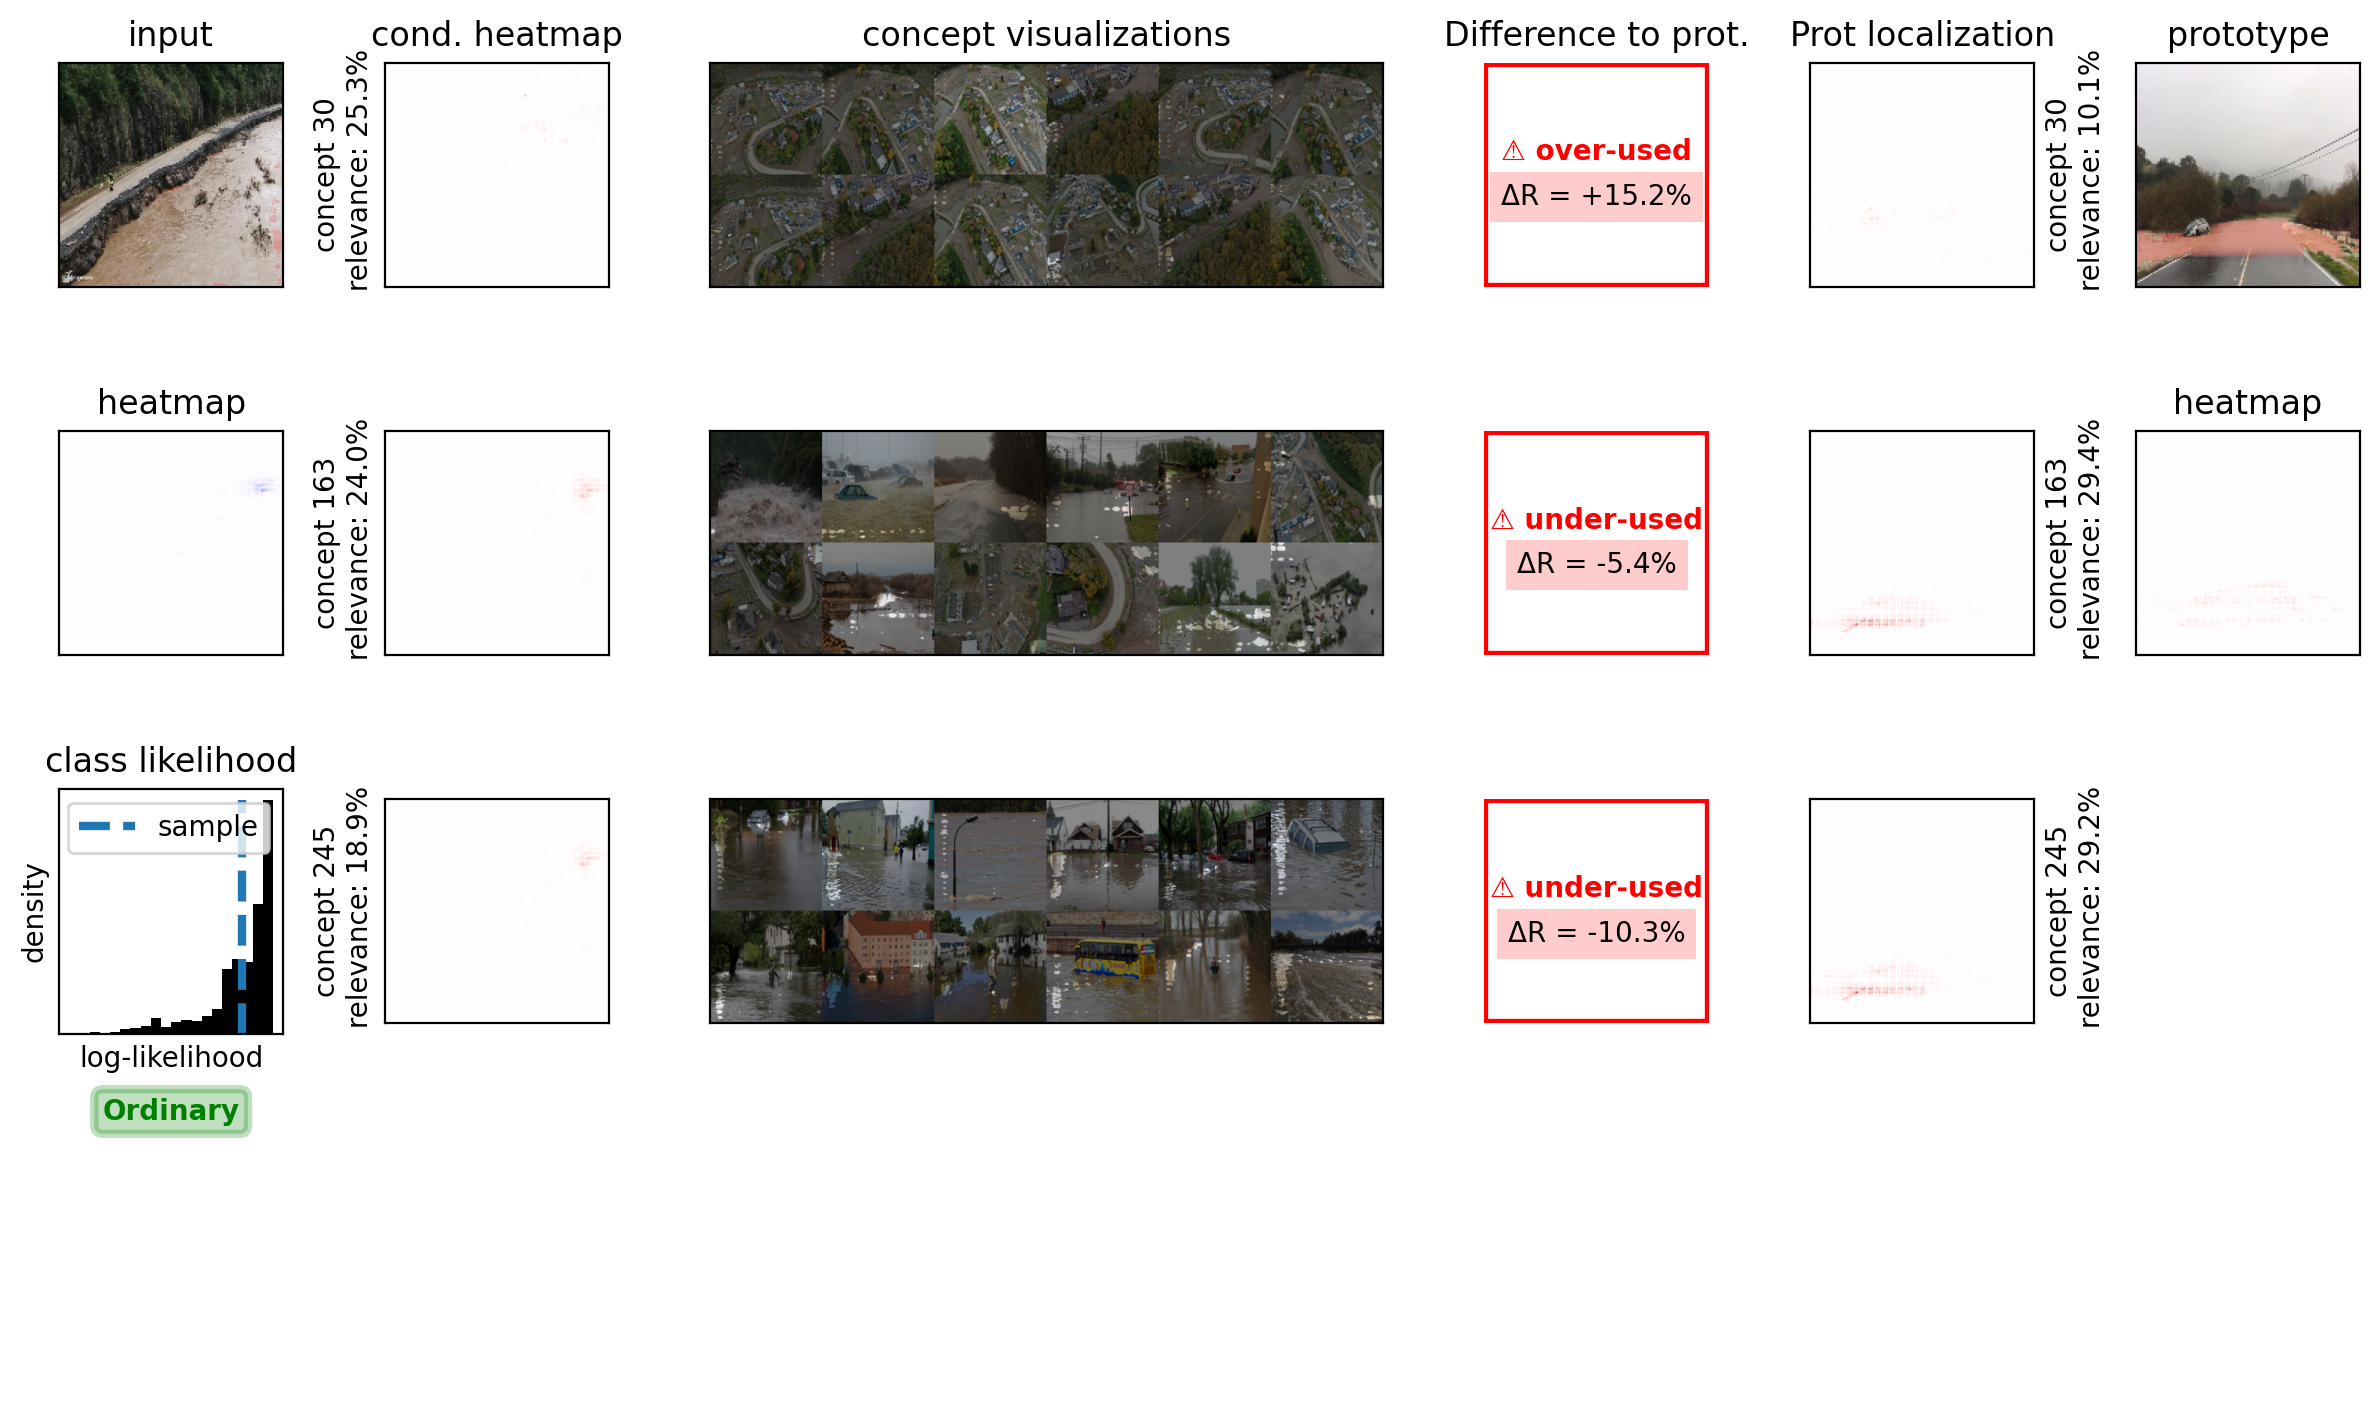

In [13]:
#cell 11
from src.datasets.flood_datase_crp import FloodDataset 
import os
from src.plot_pcx_pidnet_new import plot_pcx_explanations
root_dir = "../data/BRK-data/"
dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded dataset:', type(dataset))
print('len(dataset) =', len(dataset))

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Use parent-relative paths because this notebook lives in the `examples/` folder
output_dir_crp = "../examples/output/crp/CRP-BRK-NEW/"
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"




plot_pcx_explanations(
    "pidnet",
    model.to(device),
    dataset,
    sample_id=925,
    layer_name='layer5.1.conv1',
    n_concepts=3,
    n_refimgs=12,
    num_prototypes=5,
    ref_imgs_path="../examples/new-ref-img-BRK",
    output_dir_crp=output_dir_crp,
    output_dir_pcx=output_dir_pcx,
)   

In [14]:
from src.plot_pcx_pidnet_new import plot_one_image_pcx_explanation 

output_dir_crp = "../examples/output/crp/CRP-BRK-NEW/"
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"
img= '/home/heydari/FHHI-XAI/data/Mantoudi/flood_segmentation/RGB/Flood_1057.jpg'
ref_imgs_path = "../examples/new-ref-img-BRK"
fig = plot_one_image_pcx_explanation(
        model_name=model_name,
        model=model,
        img=img,
        dataset=dataset,
        sample_id=1,
        layer='layer5.1.conv1',
        n_concepts=3,
        num_prototypes=5,
        n_refimgs=12,
        ref_imgs_path=ref_imgs_path,
        output_dir_crp=output_dir_crp,
        output_dir_pcx=output_dir_pcx,
    )

[plot_one_image_pcx_explanation] device=cpu, layer=layer5.1.conv1
[attr] building attribution/composite/visualization
[attr] layer_map size=79


TypeError: string indices must be integers

In [7]:
# Cell: Mantoudi image + BRK train refs
import os
from pathlib import Path
import torch

from src.datasets.flood_test import FloodDataset
from src.plot_pcx_pidnet_new import plot_one_image_pcx_explanation

print("cwd:", os.getcwd())

# Find repo root
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data").exists() and (p / "src").exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root (missing data/ and src/).")

# Single test image (no label)
img_path = repo_root / "data" / "Mantoudi" / "flood_segmentation" / "RGB" / "Flood_1057.jpg"
print("img_path:", img_path)
print("exists:", img_path.is_file())
if not img_path.is_file():
    raise FileNotFoundError(f"Image not found: {img_path}")

dataset_single = FloodDataset(root_dir=str(img_path), transform=transform)
print("len(dataset_single) =", len(dataset_single))  # should be 1

# BRK train images for reference/prototypes
brk_rgb_train = repo_root / "data" / "BRK-data" / "RGB" / "train"
print("brk_rgb_train:", brk_rgb_train)
print("brk train exists:", brk_rgb_train.is_dir())
dataset_ref = FloodDataset(root_dir=str(brk_rgb_train), transform=transform)
print("len(dataset_ref) =", len(dataset_ref))

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Use BRK CRP/PCX outputs
output_dir_crp = str(repo_root / "examples" / "output" / "crp" / "CRP-BRK-NEW")
output_dir_pcx = str(repo_root / "examples" / "output" / "pcx" / "PCX-BRK-NEW")
ref_imgs_path = str(repo_root / "examples" / "new-ref-img-BRK")

# Run: Mantoudi image + BRK train reference bank
img, _ = dataset_single[0]

fig = plot_one_image_pcx_explanation(
    model_name="pidnet",
    model=model.to(device),        # BRK weights already loaded
    img=img,
    dataset=dataset_ref,           # BRK train images for refs/prototypes
    sample_id=0,                   # any valid BRK train index
    layer="layer3.1.conv1",
    n_concepts=3,
    num_prototypes=9,
    n_refimgs=12,
    ref_imgs_path=ref_imgs_path,
    output_dir_crp=output_dir_crp,
    output_dir_pcx=output_dir_pcx,
)


DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


cwd: /home/heydari/FHHI-XAI/examples
img_path: /home/heydari/FHHI-XAI/data/Mantoudi/flood_segmentation/RGB/Flood_1057.jpg
exists: True
len(dataset_single) = 1
brk_rgb_train: /home/heydari/FHHI-XAI/data/BRK-data/RGB/train
brk train exists: True


AssertionError: No images found in /home/heydari/FHHI-XAI/data/BRK-data/RGB/train

In [ ]:
from pathlib import Path
import types, sys, importlib.util
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.datasets.flood_test import FloodDataset  # handles flat Mantoudi layout

model_name = "pidnet"
ckpt_path = Path("../models/flood_model.pt")
root_dir = Path("../data/Mantoudi/flood_segmentation")

if not ckpt_path.exists():
    ckpt_path = Path("models/flood_model.pt")
if not root_dir.exists():
    root_dir = Path("data/Mantoudi/flood_segmentation")

dataset = FloodDataset(root_dir=str(root_dir), transform=None, multi_scale=False, flip=False)
print("Loaded dataset:", type(dataset))
print("len(dataset) =", len(dataset))

sample_id = 0
image, label = dataset[sample_id]  # torch tensors
print("image:", tuple(image.shape), "label:", tuple(label.shape), "label unique:", torch.unique(label))

# Load PIDNet without pulling in segmentation_models_pytorch
pkg = types.ModuleType("LCRP")
pkg.__path__ = [str(Path("LCRP"))]
sys.modules.setdefault("LCRP", pkg)
models_pkg = types.ModuleType("LCRP.models")
models_pkg.__path__ = [str(Path("LCRP/models"))]
sys.modules.setdefault("LCRP.models", models_pkg)

pidnet_path = Path("LCRP/models/pidnet.py")
spec = importlib.util.spec_from_file_location("LCRP.models.pidnet", pidnet_path)
pidnet = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = pidnet
spec.loader.exec_module(pidnet)
get_pidnet = pidnet.get_pidnet

model = get_pidnet(model_name=model_name, ckpt_path=str(ckpt_path), device="cpu")
model.eval()

with torch.no_grad():
    out = model(image.unsqueeze(0))
    if isinstance(out, (list, tuple)):
        out = out[1]
    pred = out.argmax(dim=1).squeeze(0)

pred_flood = pred == 1
gt_flood = label == 1
inter = (pred_flood & gt_flood).sum().item()
union = (pred_flood | gt_flood).sum().item()
iou = inter / union if union else 0.0

print("pred flood pixels:", int(pred_flood.sum()))
print("gt flood pixels:", int(gt_flood.sum()))
print("IoU:", iou)
print("predicts any flood?", bool(pred_flood.any()))

# Visual check
img_vis = dataset.reverse_augmentation(image).byte().permute(1, 2, 0).numpy()
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("image"); plt.imshow(img_vis); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("gt flood"); plt.imshow(gt_flood.cpu(), cmap="gray"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("pred flood"); plt.imshow(pred_flood.cpu(), cmap="gray"); plt.axis("off")
plt.show()


In [ ]:
# Cell: MANTOUDI single image only (no labels)
import os
from pathlib import Path
import numpy as np
import torch

from src.datasets.flood_test import FloodDataset
from src.plot_pcx_pidnet_new import plot_pcx_explanations
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names
from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES

print("cwd:", os.getcwd())

# Find repo root
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data").exists() and (p / "src").exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root (missing data/ and src/).")

# Single test image
img_path = repo_root / "data" / "Mantoudi" / "flood_segmentation" / "RGB" / "Flood_1057.jpg"
print("img_path:", img_path)
print("exists:", img_path.is_file())
if not img_path.is_file():
    raise FileNotFoundError(f"Image not found: {img_path}")

dataset = FloodDataset(root_dir=str(img_path), transform=transform)
print("len(dataset) =", len(dataset))  # should be 1

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Output folders for THIS single-image run
output_dir_crp = str(repo_root / "examples" / "output" / "crp" / "CRP-BRK-ONE")
output_dir_pcx = str(repo_root / "examples" / "output" / "pcx" / "PCX-BRK-ONE")
ref_imgs_path = str(repo_root / "examples" / "output" / "ref_images_mantoudi_one")

# --- Build attribution bank from THIS single image ---
model_name = "pidnet"
class_id = 1  # flood class
layer_names = get_layer_names(model, [torch.nn.Conv2d])

attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
condition = [{"y": class_id}]

fv = VISUALIZATIONS[model_name](
    attribution, dataset, layer_names,
    preprocess_fn=lambda x: x, path=output_dir_crp, max_target="max"
)

model.to(device).eval()
cc = ChannelConcept()

activations = {ln: [] for ln in layer_names}
attributions = {ln: [] for ln in layer_names}

for x, _ in dataset:
    x = x.to(device).requires_grad_()
    attr = attribution(x.unsqueeze(0), condition, composite, record_layer=layer_names)

    for ln in layer_names:
        if ln not in attr.activations or ln not in attr.relevances:
            continue
        acts = attr.activations[ln].amax((-2, -1)).detach().cpu()
        rels = cc.attribute(attr.relevances[ln], abs_norm=True).detach().cpu()
        acts = torch.nan_to_num(acts, nan=0.0, posinf=0.0, neginf=0.0)
        rels = torch.nan_to_num(rels, nan=0.0, posinf=0.0, neginf=0.0)
        activations[ln].append(acts)
        attributions[ln].append(rels)

for ln in layer_names:
    if not attributions[ln]:
        continue
    act_tensor = torch.cat(activations[ln])
    rel_tensor = torch.cat(attributions[ln])
    folder = os.path.join(output_dir_pcx, ln)
    os.makedirs(folder, exist_ok=True)
    np.save(os.path.join(folder, "activations.npy"), act_tensor.numpy())
    np.save(os.path.join(folder, "attributions.npy"), rel_tensor.numpy())

# --- Run PCX on this single image ---
plot_pcx_explanations(
    "pidnet",
    model.to(device),
    dataset,
    sample_id=0,
    layer_name="layer3.1.conv1",
    n_concepts=3,
    n_refimgs=1,       # only one image exists
    num_prototypes=1,  # single-image bank => only 1 prototype
    ref_imgs_path=ref_imgs_path,
    output_dir_crp=output_dir_crp,
    output_dir_pcx=output_dir_pcx,
)


cwd: /home/heydari/FHHI-XAI/examples
img_path: /home/heydari/FHHI-XAI/data/Mantoudi/flood_segmentation/RGB/Flood_1057.jpg
exists: True
len(dataset) = 1
[plot_pcx_explanations] starting
[plot_pcx_explanations] sample_id=0 img.shape=(3, 1280, 720)
[plot_one_image_pcx_explanation] device=cpu, layer=layer3.1.conv1
[attr] building attribution/composite/visualization
[attr] layer_map size=79
[data] x.shape=(1, 3, 1280, 720)
[attr] computing base attribution
[attr] base heatmap computed
[mask] building predicted mask
[mask] reverse_augmentation available, target size=(1280, 720)
[mask] resized mask -> (1280, 720)
[concepts] computing channel relevances
[concepts] channel_rels shape=(1, 128)
[concepts] topk_ind=[117, 80, 66] topk_rel=[0.009999999776482582, 0.008999999612569809, 0.008999999612569809]
[attr] computing conditional heatmaps
[refs] computing/loading reference images
[get_ref_images] start; layer=layer3.1.conv1, n_ref=1, cache=/home/heydari/FHHI-XAI/examples/output/ref_images_mantou

FileNotFoundError: [Errno 2] No such file or directory: '/home/heydari/FHHI-XAI/examples/output/crp/CRP-MANTOODI-ONE/RelMax_sum_normed/layer3.1.conv1_data.npy'

In [7]:
from pathlib import Path
import types, sys, importlib.util
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.datasets.flood_test import FloodDataset  # handles flat Mantoudi layout

model_name = "pidnet"
ckpt_path = Path("../models/flood_model.pt")
root_dir = Path("../data/Mantoudi/flood_segmentation")

if not ckpt_path.exists():
    ckpt_path = Path("models/flood_model.pt")
if not root_dir.exists():
    root_dir = Path("data/Mantoudi/flood_segmentation")

dataset = FloodDataset(root_dir=str(root_dir), transform=None, multi_scale=False, flip=False)
print("Loaded dataset:", type(dataset))
print("len(dataset) =", len(dataset))

sample_id = 0
image, label = dataset[sample_id]  # torch tensors
print("image:", tuple(image.shape), "label:", tuple(label.shape), "label unique:", torch.unique(label))

# Load PIDNet without pulling in segmentation_models_pytorch
pkg = types.ModuleType("LCRP")
pkg.__path__ = [str(Path("LCRP"))]
sys.modules.setdefault("LCRP", pkg)
models_pkg = types.ModuleType("LCRP.models")
models_pkg.__path__ = [str(Path("LCRP/models"))]
sys.modules.setdefault("LCRP.models", models_pkg)

pidnet_path = Path("LCRP/models/pidnet.py")
spec = importlib.util.spec_from_file_location("LCRP.models.pidnet", pidnet_path)
pidnet = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = pidnet
spec.loader.exec_module(pidnet)
get_pidnet = pidnet.get_pidnet

model = get_pidnet(model_name=model_name, ckpt_path=str(ckpt_path), device="cpu")
model.eval()

with torch.no_grad():
    out = model(image.unsqueeze(0))
    if isinstance(out, (list, tuple)):
        out = out[1]
    pred = out.argmax(dim=1).squeeze(0)

pred_flood = pred == 1
gt_flood = label == 1
inter = (pred_flood & gt_flood).sum().item()
union = (pred_flood | gt_flood).sum().item()
iou = inter / union if union else 0.0

print("pred flood pixels:", int(pred_flood.sum()))
print("gt flood pixels:", int(gt_flood.sum()))
print("IoU:", iou)
print("predicts any flood?", bool(pred_flood.any()))

# Visual check
img_vis = dataset.reverse_augmentation(image).byte().permute(1, 2, 0).numpy()
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("image"); plt.imshow(img_vis); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("gt flood"); plt.imshow(gt_flood.cpu(), cmap="gray"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("pred flood"); plt.imshow(pred_flood.cpu(), cmap="gray"); plt.axis("off")
plt.show()


Loaded dataset: <class 'src.datasets.flood_test.FloodDataset'>
len(dataset) = 339
image: (3, 1280, 720) label: (1280, 720) label unique: tensor([0])


FileNotFoundError: [Errno 2] No such file or directory: '/home/heydari/FHHI-XAI/examples/LCRP/models/pidnet.py'

In [39]:
# Find sample 925 in BRK dataset
import os

sample_id_search = 925

print(f"{'='*90}")
print(f"SEARCHING FOR SAMPLE {sample_id_search}")
print(f"{'='*90}\n")

dataset_size = len(brk_dataset)
print(f"BRK Dataset size: {dataset_size}")
print(f"Valid sample_ids: 0 to {dataset_size - 1}")

if sample_id_search >= dataset_size or sample_id_search < 0:
    print(f"\n❌ ERROR: sample_id={sample_id_search} is OUT OF RANGE!")
    print(f"Please choose a sample_id between 0 and {dataset_size - 1}")
else:
    print(f"\n✓ sample_id={sample_id_search} is VALID\n")
    
    file_info = brk_dataset.files[sample_id_search]
    img_path = str(file_info["img"])
    label_path = str(file_info["label"])
    
    print(f"{'='*90}")
    print(f"SAMPLE DETAILS")
    print(f"{'='*90}")
    print(f"Sample ID: {sample_id_search}")
    print(f"Image filename: {os.path.basename(img_path)}")
    print(f"Image path: {img_path}")
    print(f"Label path: {label_path}")
    print(f"{'='*90}\n")
    
    # Check if it's an outlier
    if 'outlier_indices_original' in dir() and len(outlier_indices_original) > 0:
        if sample_id_search in outlier_indices_original:
            outlier_pos = np.where(outlier_indices_original == sample_id_search)[0][0]
            print(f"🚨 This sample IS an OUTLIER!")
            print(f"   Rank: #{outlier_pos + 1} most anomalous")
            print(f"   Score: {outlier_scores[outlier_pos]:.4f}")
        else:
            print(f"✓ This sample is ORDINARY (not an outlier)")
    else:
        print(f"ℹ Run the outlier detection cell first to check if this is an outlier")

SEARCHING FOR SAMPLE 925

BRK Dataset size: 1321
Valid sample_ids: 0 to 1320

✓ sample_id=925 is VALID

SAMPLE DETAILS
Sample ID: 925
Image filename: image_571.jpg
Image path: ../data/BRK-data/RGB/train/JPEG/image_571.jpg
Label path: ../data/BRK-data/annotations/train/JPEG/image_571Ids.jpg

🚨 This sample IS an OUTLIER!
   Rank: #2 most anomalous
   Score: 134.3486


In [7]:
# Find outliers by GMM p1 threshold (reusing variables from cell 11)
import numpy as np
from sklearn.mixture import GaussianMixture

# Reuse layer_name and output_dir_pcx from cell 11
layer_name = "layer4.1.conv1"
n_outliers = 20

# Load attributions
attr_path = f"{output_dir_pcx}/{layer_name}/attributions.npy"
X = np.load(attr_path)

# Clean data (same as plot_pcx_explanations)
finite_mask = np.isfinite(X).all(axis=1)
X_clean = X[finite_mask]
X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
nonzero_mask = ~(np.isclose(X_clean.std(axis=1), 0.0) & np.isclose(X_clean.mean(axis=1), 0.0))
X_clean = X_clean[nonzero_mask]

# Fit GMM
gmm = GaussianMixture(n_components=7, reg_covar=1e-5, random_state=0).fit(X_clean)
scores = gmm.score_samples(X_clean)

# Find outliers at p1 threshold
p1 = np.percentile(scores, 1)
outlier_idx = np.where(scores < p1)[0]
outlier_idx = outlier_idx[np.argsort(scores[outlier_idx])]

print("Outlier indices (p1 threshold):")
print(outlier_idx[:n_outliers].tolist())

print("\nLowest-score outliers (idx, score):")
for i in outlier_idx[:n_outliers]:
    print(f"  {int(i):4d}  {float(scores[i]):8.4f}")

Outlier indices (p1 threshold):
[326, 1163, 477, 284, 138, 36, 833, 80, 1160, 103, 257, 1074]

Lowest-score outliers (idx, score):
   326  1171.5190
  1163  1171.5266
   477  1171.9791
   284  1173.6156
   138  1174.9696
    36  1175.1022
   833  1175.2219
    80  1176.3907
  1160  1177.1682
   103  1177.1724
   257  1177.2307
  1074  1177.3667


In [8]:
# Calculate labels for all samples and collect outliers
import numpy as np
from sklearn.mixture import GaussianMixture

layer_name = "layer4.1.conv1"  # change to your layer
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"

# Load attributions
attr_path = f"{output_dir_pcx}/{layer_name}/attributions.npy"
X = np.load(attr_path)

print(f"Loaded attributions shape: {X.shape}")

# Clean data (same as plot_pcx_explanations)
finite_mask = np.isfinite(X).all(axis=1)
X_clean = X[finite_mask]
X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
nonzero_mask = ~(np.isclose(X_clean.std(axis=1), 0.0) & np.isclose(X_clean.mean(axis=1), 0.0))
X_clean = X_clean[nonzero_mask]

print(f"After cleaning: {X_clean.shape}")

# Fit GMM
gmm = GaussianMixture(n_components=7, reg_covar=1e-5, random_state=0).fit(X_clean)
scores = gmm.score_samples(X_clean)

# Calculate p1 threshold
p1 = np.percentile(scores, 1)
print(f"\np1 threshold (1st percentile): {p1:.4f}")

# Loop through all samples and assign labels
labels = {}
outliers = []

for i in range(len(scores)):
    label = "Outlier" if scores[i] < p1 else "Ordinary"
    labels[i] = label
    
    if label == "Outlier":
        outliers.append((i, scores[i]))

# Sort outliers by score (lowest first)
outliers.sort(key=lambda x: x[1])

# Print summary
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Total samples: {len(scores)}")
print(f"Outliers: {len(outliers)}")
print(f"Ordinary: {len(scores) - len(outliers)}")

print(f"\n{'='*60}")
print(f"OUTLIER LIST (sorted by score, lowest first)")
print(f"{'='*60}")
print(f"{'Index':<8} {'Score':<12} {'Label'}")
print(f"{'-'*60}")
for idx, score in outliers:
    print(f"{idx:<8} {score:<12.4f} Outlier")

print(f"\nOutlier indices: {[idx for idx, _ in outliers]}")

Loaded attributions shape: (1321, 256)
After cleaning: (1173, 256)

p1 threshold (1st percentile): 1177.9482

SUMMARY
Total samples: 1173
Outliers: 12
Ordinary: 1161

OUTLIER LIST (sorted by score, lowest first)
Index    Score        Label
------------------------------------------------------------
326      1171.5190    Outlier
1163     1171.5266    Outlier
477      1171.9791    Outlier
284      1173.6156    Outlier
138      1174.9696    Outlier
36       1175.1022    Outlier
833      1175.2219    Outlier
80       1176.3907    Outlier
1160     1177.1682    Outlier
103      1177.1724    Outlier
257      1177.2307    Outlier
1074     1177.3667    Outlier

Outlier indices: [326, 1163, 477, 284, 138, 36, 833, 80, 1160, 103, 257, 1074]


In [ ]:
# Robust: 7 prototypes, 2 samples per prototype, skip proto 4, renumber titles
import numpy as np
from sklearn.cluster import KMeans

N_PROTOTYPES = 7
samples_per_proto = 2
skip_proto = 4

X = attributions.detach().cpu().numpy()
unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = [[] for _ in range(N_PROTOTYPES)]

if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        topk = idx[np.argsort(d)[:samples_per_proto]]
        proto_samples[k] = list(map(int, topk))

# fill missing samples globally to keep grid full
used = set(s for lst in proto_samples for s in lst)
remaining = [i for i in range(len(X)) if i not in used]

def pick_farthest(chosen, pool):
    if not pool:
        return None
    if not chosen:
        return pool.pop(0)
    dists = np.min(
        np.linalg.norm(X[pool][:, None, :] - X[list(chosen)][None, :, :], axis=2),
        axis=1
    )
    pick_idx = int(np.argmax(dists))
    return pool.pop(pick_idx)

for k in range(N_PROTOTYPES):
    while len(proto_samples[k]) < samples_per_proto and remaining:
        pick = pick_farthest(used, remaining)
        if pick is None:
            break
        proto_samples[k].append(pick)
        used.add(pick)

# plot 2 rows, 6 columns (skip proto 4), renumber titles
plot_indices = [k for k in range(N_PROTOTYPES) if k != skip_proto]
title_prefix = "Flood Proto"

fig, axs = plt.subplots(
    samples_per_proto,
    len(plot_indices),
    figsize=(1.6 * len(plot_indices), 1.6 * samples_per_proto),
    dpi=200,
    facecolor="white"
)
axs = np.atleast_2d(axs)

for col, proto_k in enumerate(plot_indices):
    for row in range(samples_per_proto):
        ax = axs[row, col]
        if row >= len(proto_samples[proto_k]):
            ax.axis("off")
            continue
        sample_id = proto_samples[proto_k][row]
        img = imgify(dataset[int(sample_id)][0])
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{title_prefix} {col}", fontsize=8)

plt.tight_layout()


In [ ]:
#cell 11

# Loading
layer_names = get_layer_names(model, [torch.nn.Conv2d])
layer_name = layer_names[53]
print(layer_name)
folder = f"/home/heydari/FHHI-XAI/examples/output/pcx/PCX-BRK-NEW/{layer_name}/"
attributions = torch.from_numpy(np.load(folder + "attributions.npy"))
activations = torch.from_numpy(np.load(folder + "activations.npy"))
indices = np.arange(len(dataset))

num_prototypes = {
   
}

In [ ]:
#cell 12
from umap import UMAP


embedding_attr = UMAP(n_neighbors=5, random_state=123, n_jobs=1)
X_attr = embedding_attr.fit_transform(attributions.detach().cpu().numpy())
x_attr, y_attr = X_attr[:, 0], X_attr[:, 1]

embedding_act = UMAP(n_neighbors=5, random_state=123, n_jobs=1)
X_act = embedding_act.fit_transform(activations.detach().cpu().numpy())
x_act, y_act = X_act[:, 0], X_act[:, 1]

In [ ]:
#cell 13

from scipy import stats
from sklearn.mixture import GaussianMixture

N_PROTOTYPES = 3

fig, axes = plt.subplots(1, 2, dpi=300, figsize=(5, 3), facecolor='white')
for i, X in enumerate([X_attr, X_act]):
    x, y = X[:, 0], X[:, 1]
    xmin = x.min() - 2
    xmax = x.max() + 2
    ymin = y.min() - 2
    ymax = y.max() + 2
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([x, y])
    kernel = stats.gaussian_kde(values, 0.5)
    Z = np.reshape(kernel(positions).T, X.shape).T
    axes[i].contour(Z, extent=[xmin, xmax, ymin, ymax], cmap="Greys", alpha=0.3, extend='min', vmax=Z.max() * 1, zorder=0)
    axes[i].scatter(x, y, s=3, alpha=0.7, zorder=1)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(["attributions", "activations"][i])
    axes[i].plot([1], y[1], 'ko', markersize=5, label="test image")
    axes[i].legend()


prototypes = []
gmms = []
for i, (X, emb) in enumerate([(attributions, embedding_attr), (activations, embedding_act)]):
    gmms.append(GaussianMixture(n_components=N_PROTOTYPES, random_state=None, n_init=10).fit(X.detach().cpu().numpy()))
    prototypes.append(gmms[-1].means_)
    mean = emb.transform(gmms[-1].means_)
    axes[i].scatter(mean[:, 0], mean[:, 1], s=30, c="#1B4365", zorder=2, label="prototypes")
    for k, prot in enumerate(mean):
        axes[i].text(prot[0], prot[1], k, fontsize=4, color="white", ha="center", va="center")
    axes[i].legend()

plt.tight_layout()
fig.show()

In [ ]:
#cell 13

print("Layer name:", layer_name)
print("X shape:", X.shape)
print("Unique values in X:", len(np.unique(X.detach().cpu().numpy().flatten())))
print("N_PROTOTYPES:", N_PROTOTYPES)
print("Mode:", mode)
print("X min/max:", X.min().item(), X.max().item())
print("Layer names:", layer_names)

In [ ]:
# 5 prototypes, 1 sample each (from scratch)
import numpy as np
from sklearn.cluster import KMeans

N_PROTOTYPES = 5
samples_per_proto = 1

X = attributions.detach().cpu().numpy()

kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# closest sample to each cluster center
proto_samples = []
for k in range(N_PROTOTYPES):
    idx = np.where(labels == k)[0]
    if len(idx) == 0:
        proto_samples.append(-1)
        continue
    d = np.linalg.norm(X[idx] - centers[k], axis=1)
    proto_samples.append(int(idx[np.argmin(d)]))

# plot one row, five columns
title_prefix = "Flood Proto"
fig, axs = plt.subplots(
    1,
    N_PROTOTYPES,
    figsize=(1.8 * N_PROTOTYPES, 2.4),
    dpi=200,
    facecolor="white"
)
axs = np.atleast_1d(axs)

for col in range(N_PROTOTYPES):
    ax = axs[col]
    sample_id = proto_samples[col]
    if sample_id < 0:
        ax.axis("off")
        continue
    img = imgify(dataset[sample_id][0])
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {col}", fontsize=8)

plt.tight_layout()


In [ ]:
# Robust: always return 5 prototype samples
import numpy as np
from sklearn.cluster import KMeans

N_PROTOTYPES = 7
X = attributions.detach().cpu().numpy()

# if attributions are too degenerate, fall back to activations
unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

# cluster if possible
labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = []

if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            proto_samples.append(-1)
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        proto_samples.append(int(idx[np.argmin(d)]))

# fill missing or if clustering wasn't possible
if len(proto_samples) < N_PROTOTYPES or any(s < 0 for s in proto_samples):
    chosen = [s for s in proto_samples if s >= 0]
    remaining = [i for i in range(len(X)) if i not in chosen]
    # greedy farthest-point selection to diversify
    while len(chosen) < N_PROTOTYPES and remaining:
        if not chosen:
            chosen.append(remaining.pop(0))
            continue
        dists = np.min(
            np.linalg.norm(X[remaining][:, None, :] - X[chosen][None, :, :], axis=2),
            axis=1
        )
        pick = remaining[int(np.argmax(dists))]
        chosen.append(pick)
        remaining.remove(pick)
    proto_samples = chosen[:N_PROTOTYPES]

# plot one row, five columns
title_prefix = "Flood Proto"
fig, axs = plt.subplots(
    1, N_PROTOTYPES, figsize=(1.8 * N_PROTOTYPES, 2.4), dpi=200, facecolor="white"
)
axs = np.atleast_1d(axs)

for col in range(N_PROTOTYPES):
    ax = axs[col]
    sample_id = proto_samples[col]
    img = imgify(dataset[int(sample_id)][0])
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {col}", fontsize=8)

plt.tight_layout()


In [ ]:
# Robust: 7 prototypes, 3 samples per prototype
import numpy as np
from sklearn.cluster import KMeans

N_PROTOTYPES = 7
samples_per_proto = 3

X = attributions.detach().cpu().numpy()
unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = [[] for _ in range(N_PROTOTYPES)]

if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        topk = idx[np.argsort(d)[:samples_per_proto]]
        proto_samples[k] = list(map(int, topk))

# fill missing samples globally to keep grid full
used = set(s for lst in proto_samples for s in lst)
remaining = [i for i in range(len(X)) if i not in used]

def pick_farthest(chosen, pool):
    if not pool:
        return None
    if not chosen:
        return pool.pop(0)
    dists = np.min(
        np.linalg.norm(X[pool][:, None, :] - X[list(chosen)][None, :, :], axis=2),
        axis=1
    )
    pick_idx = int(np.argmax(dists))
    return pool.pop(pick_idx)

for k in range(N_PROTOTYPES):
    while len(proto_samples[k]) < samples_per_proto and remaining:
        pick = pick_farthest(used, remaining)
        if pick is None:
            break
        proto_samples[k].append(pick)
        used.add(pick)

# plot 3 rows, 7 columns
title_prefix = "Flood Proto"
fig, axs = plt.subplots(
    samples_per_proto,
    N_PROTOTYPES,
    figsize=(1.6 * N_PROTOTYPES, 1.6 * samples_per_proto),
    dpi=200,
    facecolor="white"
)
axs = np.atleast_2d(axs)

for col in range(N_PROTOTYPES):
    for row in range(samples_per_proto):
        ax = axs[row, col]
        if row >= len(proto_samples[col]):
            ax.axis("off")
            continue
        sample_id = proto_samples[col][row]
        img = imgify(dataset[int(sample_id)][0])
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{title_prefix} {col}", fontsize=8)

plt.tight_layout()


In [ ]:
# Robust: 7 prototypes, 2 samples per prototype, skip proto 4, renumber titles
import numpy as np
from sklearn.cluster import KMeans

N_PROTOTYPES = 7
samples_per_proto = 2
skip_proto = 4

X = attributions.detach().cpu().numpy()
unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = [[] for _ in range(N_PROTOTYPES)]

if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        topk = idx[np.argsort(d)[:samples_per_proto]]
        proto_samples[k] = list(map(int, topk))

# fill missing samples globally to keep grid full
used = set(s for lst in proto_samples for s in lst)
remaining = [i for i in range(len(X)) if i not in used]

def pick_farthest(chosen, pool):
    if not pool:
        return None
    if not chosen:
        return pool.pop(0)
    dists = np.min(
        np.linalg.norm(X[pool][:, None, :] - X[list(chosen)][None, :, :], axis=2),
        axis=1
    )
    pick_idx = int(np.argmax(dists))
    return pool.pop(pick_idx)

for k in range(N_PROTOTYPES):
    while len(proto_samples[k]) < samples_per_proto and remaining:
        pick = pick_farthest(used, remaining)
        if pick is None:
            break
        proto_samples[k].append(pick)
        used.add(pick)

# plot 2 rows, 6 columns (skip proto 4), renumber titles
plot_indices = [k for k in range(N_PROTOTYPES) if k != skip_proto]
title_prefix = "Flood Proto"

fig, axs = plt.subplots(
    samples_per_proto,
    len(plot_indices),
    figsize=(1.6 * len(plot_indices), 1.6 * samples_per_proto),
    dpi=200,
    facecolor="white"
)
axs = np.atleast_2d(axs)

for col, proto_k in enumerate(plot_indices):
    for row in range(samples_per_proto):
        ax = axs[row, col]
        if row >= len(proto_samples[proto_k]):
            ax.axis("off")
            continue
        sample_id = proto_samples[proto_k][row]
        img = imgify(dataset[int(sample_id)][0])
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{title_prefix} {col}", fontsize=8)

plt.tight_layout()


In [ ]:
# 7 prototypes (skip 4), 2 samples each, 5 concepts + right-side refs (scaled)
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from crp.concepts import ChannelConcept
from crp.image import imgify

from src.plot_pcx_pidnet_new import get_ref_images

# ---- config ----
N_PROTOTYPES = 7
samples_per_proto = 2
skip_proto = 4
n_concepts = 5
title_prefix = "Flood Proto"
n_refimgs = 8
ref_imgs_path = globals().get("ref_imgs_path", "../examples/new-ref-img-BRK")
layer_name = "layer4.2.conv1"
class_id_use = class_id if "class_id" in globals() else 1

# ---- clustering (robust) ----
X = attributions.detach().cpu().numpy()
unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = [[] for _ in range(N_PROTOTYPES)]
if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        topk = idx[np.argsort(d)[:samples_per_proto]]
        proto_samples[k] = list(map(int, topk))

# fill missing samples globally
used = set(s for lst in proto_samples for s in lst)
remaining = [i for i in range(len(X)) if i not in used]

def pick_farthest(chosen, pool):
    if not pool:
        return None
    if not chosen:
        return pool.pop(0)
    dists = np.min(
        np.linalg.norm(X[pool][:, None, :] - X[list(chosen)][None, :, :], axis=2),
        axis=1
    )
    pick_idx = int(np.argmax(dists))
    return pool.pop(pick_idx)

for k in range(N_PROTOTYPES):
    while len(proto_samples[k]) < samples_per_proto and remaining:
        pick = pick_farthest(used, remaining)
        if pick is None:
            break
        proto_samples[k].append(pick)
        used.add(pick)

# ---- concepts per sample ----
device = next(model.parameters()).device
model.eval()

attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
cc = ChannelConcept()

# ensure fv exists for reference images
if "fv" not in globals():
    layer_names = get_layer_names(model, [torch.nn.Conv2d])
    fv = VISUALIZATIONS[model_name](
        attribution, dataset, layer_names,
        preprocess_fn=lambda x: x, path=output_dir_crp, max_target="max"
    )

def top_concepts_for_sample(sample_id, k=5):
    x, _ = dataset[sample_id]
    x = x.to(device).requires_grad_()
    attr = attribution(x.unsqueeze(0), [{"y": class_id_use}], composite, record_layer=[layer_name])

    # abs-normalized per-channel relevance
    rels = cc.attribute(attr.relevances[layer_name], abs_norm=True)[0]
    topk = torch.topk(rels, k=k)
    idx = topk.indices.detach().cpu().numpy()
    vals = topk.values.detach().cpu().numpy()
    return idx, vals

plot_indices = [k for k in range(N_PROTOTYPES) if k != skip_proto]
rows_per_sample = n_concepts + 1
total_rows = samples_per_proto * rows_per_sample
total_cols = len(plot_indices) + 1  # right-side column

fig, axs = plt.subplots(
    total_rows, total_cols,
    figsize=(1.6 * total_cols, 0.5 * total_rows + 1.5),
    dpi=200,
    facecolor="white"
)
axs = np.atleast_2d(axs)

concept_scores = {}
concept_cache = {}
scale = 1e4  # display scaling

for col, proto_k in enumerate(plot_indices):
    for s in range(samples_per_proto):
        row_base = s * rows_per_sample
        sample_id = proto_samples[proto_k][s]

        ax_img = axs[row_base, col]
        img = imgify(dataset[int(sample_id)][0])
        ax_img.imshow(img)
        ax_img.set_xticks([]); ax_img.set_yticks([])
        if s == 0:
            ax_img.set_title(f"{title_prefix} {col}", fontsize=8)

        if sample_id not in concept_cache:
            concept_ids, concept_vals = top_concepts_for_sample(sample_id, k=n_concepts)
            concept_cache[sample_id] = (concept_ids, concept_vals)
        else:
            concept_ids, concept_vals = concept_cache[sample_id]

        vmax = float(np.max(concept_vals)) if len(concept_vals) else 1.0
        if vmax == 0:
            vmax = 1.0

        for r in range(n_concepts):
            ax_c = axs[row_base + 1 + r, col]
            val = float(concept_vals[r])
            norm = val / vmax
            ax_c.set_facecolor(plt.get_cmap("Reds")(norm))
            ax_c.text(
                0.5, 0.5,
                f"Concept {int(concept_ids[r])}\nval={val*scale:.3f}e-4",
                ha="center", va="center", fontsize=6, color="black"
            )
            ax_c.set_xticks([]); ax_c.set_yticks([])
            for spine in ax_c.spines.values():
                spine.set_visible(True)

            concept_scores[int(concept_ids[r])] = concept_scores.get(int(concept_ids[r]), 0.0) + val

# ---- right-side concept reference strips ----
right_col = total_cols - 1
for r in range(total_rows):
    axs[r, right_col].axis("off")

top_concepts = [c for c, _ in sorted(concept_scores.items(), key=lambda kv: kv[1], reverse=True)[:n_concepts]]
ref_imgs = get_ref_images(
    fv=fv, topk_ind=top_concepts, layer_name=layer_name,
    composite=composite, n_ref=n_refimgs, ref_imgs_save_path=ref_imgs_path
)

for i, cid in enumerate(top_concepts):
    ax = axs[i + 1, right_col]
    ax.axis("on")
    ax.set_title(f"Concept {cid} refs", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    imgs = ref_imgs.get(int(cid), [])
    if imgs:
        row_imgs = []
        for im in imgs[:n_refimgs]:
            row_imgs.append(torch.from_numpy(np.array(im)).permute(2, 0, 1))
        grid = torch.cat(list(row_imgs), dim=2)
        ax.imshow(grid.permute(1, 2, 0))
    else:
        ax.text(0.5, 0.5, "no refs", ha="center", va="center", fontsize=6)

plt.tight_layout()


In [ ]:
# quick check for relevances at layer4.2.conv1
layer_name = "layer4.2.conv1"

x, _ = dataset[0]
x = x.to(next(model.parameters()).device).requires_grad_()
attr = ATTRIBUTORS[model_name](model)(x.unsqueeze(0), [{"y": class_id}], COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()]), record_layer=[layer_name])

rel = attr.relevances[layer_name]
print("relevances shape:", rel.shape)
print("min/max:", rel.min().item(), rel.max().item())
print("sum abs:", rel.abs().sum().item())


In [ ]:
from umap import UMAP


embedding_attr = UMAP(n_neighbors=5, random_state=123, n_jobs=1)
X_attr = embedding_attr.fit_transform(attributions.detach().cpu().numpy())
x_attr, y_attr = X_attr[:, 0], X_attr[:, 1]

embedding_act = UMAP(n_neighbors=5, random_state=123, n_jobs=1)
X_act = embedding_act.fit_transform(activations.detach().cpu().numpy())
x_act, y_act = X_act[:, 0], X_act[:, 1]

In [ ]:
from pathlib import Path
import datetime

p = Path("/home/heydari/FHHI-XAI/examples/output/pcx/pidnet_flood_BRK/layer3.1.conv2/activations.npy")
mtime = p.stat().st_mtime
print("mtime (timestamp):", mtime)
print("mtime (human):", datetime.datetime.fromtimestamp(mtime))

In [ ]:
dataloader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=8)
cc = ChannelConcept()

layer_names = get_layer_names(model, [torch.nn.Conv2d])
# # Setting up CRP 
attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
condition = [{"y": 1}]  
fv = VISUALIZATIONS[model_name](attribution,
                                 dataset,
                                 layer_names,
                                 preprocess_fn=lambda x: x,
                                 path=output_dir,
                                 max_target="max")

# # Runs faster on MPS
#device = "mps"
model.to(device)
model.eval()

start = datetime.now()

activations = {}
attributions = {}
for i, (x, y) in enumerate(tqdm(dataset)):
     x = x.to(device).requires_grad_()
     condition = [{"y": 1}]
     attr = attribution(x.unsqueeze(0), condition, composite, record_layer=layer_names)

     for layer_name in layer_names:
         if layer_name in attr.activations.keys():
             if layer_name not in attributions.keys():
                 attributions[layer_name] = []
                 activations[layer_name] = []
             activations[layer_name].append(attr.activations[layer_name].amax((-2, -1)))
             attributions[layer_name].append(cc.attribute(attr.relevances[layer_name], abs_norm=True))

for layer_name in layer_names:
    if layer_name in attribution.keys():
        attributions[layer_name] = torch.cat(attributions[layer_name])
        activations[layer_name] = torch.cat(activations[layer_name])    
        folder = f"output/pcx/pidnet_flood_BRK/{layer_name}/"
        attributions[layer_name] = torch.cat(attributions[layer_name])
        activations[layer_name] = torch.cat(activations[layer_name])
        os.makedirs(folder, exist_ok=True)
        np.save(folder + "attributions", attributions[layer_name].cpu().numpy())
        np.save(folder + "activations", activations[layer_name].cpu().numpy())
end = datetime.now()

In [ ]:
# BIG images + BIG concept boxes; blue for negative; skip proto 6 in plot
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from crp.concepts import ChannelConcept
from crp.image import imgify
from PIL import Image

from src.plot_pcx_pidnet_new import get_ref_images
from crp.helper import get_layer_names

# ---- config ----
N_PROTOTYPES = 7
samples_per_proto = 1
skip_proto = 6  # removed from plot
n_concepts = 5
title_prefix = "Flood Proto"
n_refimgs = 8
ref_imgs_path = globals().get("ref_imgs_path", "../examples/new-ref-img-BRK")

layer_name = "layer4.2.conv1"
class_id_use = class_id if "class_id" in globals() else 1

# image scaling
proto_scale = 2.0
ref_thumb_scale = 2.0

# ---- clustering (robust) ----
if isinstance(attributions, dict):
    X = attributions[layer_name].detach().cpu().numpy()
else:
    X = attributions.detach().cpu().numpy()

unique_rows = np.unique(X, axis=0).shape[0]
if unique_rows < N_PROTOTYPES and "activations" in globals():
    if isinstance(activations, dict):
        X = activations[layer_name].detach().cpu().numpy()
    else:
        X = activations.detach().cpu().numpy()
    unique_rows = np.unique(X, axis=0).shape[0]

labels = None
centers = None
if unique_rows >= N_PROTOTYPES:
    kmeans = KMeans(n_clusters=N_PROTOTYPES, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

proto_samples = [[] for _ in range(N_PROTOTYPES)]
if labels is not None:
    for k in range(N_PROTOTYPES):
        idx = np.where(labels == k)[0]
        if len(idx) == 0:
            continue
        d = np.linalg.norm(X[idx] - centers[k], axis=1)
        topk = idx[np.argsort(d)[:samples_per_proto]]
        proto_samples[k] = list(map(int, topk))

# fill missing samples globally
used = set(s for lst in proto_samples for s in lst)
remaining = [i for i in range(len(X)) if i not in used]

def pick_farthest(chosen, pool):
    if not pool:
        return None
    if not chosen:
        return pool.pop(0)
    dists = np.min(
        np.linalg.norm(X[pool][:, None, :] - X[list(chosen)][None, :, :], axis=2),
        axis=1
    )
    pick_idx = int(np.argmax(dists))
    return pool.pop(pick_idx)

for k in range(N_PROTOTYPES):
    while len(proto_samples[k]) < samples_per_proto and remaining:
        pick = pick_farthest(used, remaining)
        if pick is None:
            break
        proto_samples[k].append(pick)
        used.add(pick)

# ---- concepts per sample ----
device = next(model.parameters()).device
model.eval()

attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
cc = ChannelConcept()

# ensure fv exists for reference images
if "fv" not in globals():
    layer_names = get_layer_names(model, [torch.nn.Conv2d])
    fv = VISUALIZATIONS[model_name](
        attribution, dataset, layer_names,
        preprocess_fn=lambda x: x, path=output_dir_crp, max_target="max"
    )

def top_concepts_for_sample(sample_id, k=5):
    x, _ = dataset[sample_id]
    x = x.to(device).requires_grad_()
    attr = attribution(x.unsqueeze(0), [{"y": class_id_use}], composite, record_layer=[layer_name])

    # signed per-channel relevance (allow negatives)
    rels = cc.attribute(attr.relevances[layer_name], abs_norm=False)[0]
    topk = torch.topk(rels.abs(), k=k)
    idx = topk.indices.detach().cpu().numpy()
    vals = rels[idx].detach().cpu().numpy()
    return idx, vals

# EXPLICITLY DROP PROTO 6 FROM THE PLOT
plot_indices = [k for k in range(N_PROTOTYPES) if k != skip_proto]

rows_per_sample = n_concepts + 1
total_rows = samples_per_proto * rows_per_sample
total_cols = len(plot_indices) + 1

# layout: prototype row taller; concept rows doubled height
height_ratios = [2.0] + [2.0] * n_concepts
width_ratios = [1.0] * len(plot_indices) + [2.2]

fig, axs = plt.subplots(
    total_rows, total_cols,
    figsize=(3.2 * total_cols, 1.6 * total_rows + 2.0),
    dpi=250,
    facecolor="white",
    gridspec_kw={"height_ratios": height_ratios, "width_ratios": width_ratios}
)
axs = np.atleast_2d(axs)

concept_scores = {}
concept_cache = {}
scale = 1e4
cmap = plt.get_cmap("RdBu_r")

for col, proto_k in enumerate(plot_indices):
    sample_id = proto_samples[proto_k][0]
    row_base = 0

    ax_img = axs[row_base, col]
    img = imgify(dataset[int(sample_id)][0])
    w, h = img.size
    img = img.resize((int(w * proto_scale), int(h * proto_scale)), resample=Image.BICUBIC)
    ax_img.imshow(img, aspect="auto")
    ax_img.set_xticks([]); ax_img.set_yticks([])
    ax_img.set_title(f"{title_prefix} {col}", fontsize=12)

    if sample_id not in concept_cache:
        concept_ids, concept_vals = top_concepts_for_sample(sample_id, k=n_concepts)
        concept_cache[sample_id] = (concept_ids, concept_vals)
    else:
        concept_ids, concept_vals = concept_cache[sample_id]

    vmax = float(np.max(np.abs(concept_vals))) if len(concept_vals) else 1.0
    if vmax == 0:
        vmax = 1.0

    for r in range(n_concepts):
        ax_c = axs[row_base + 1 + r, col]
        val = float(concept_vals[r])
        norm = np.clip(val / vmax, -1, 1)
        ax_c.set_facecolor(cmap((norm + 1) / 2.0))
        ax_c.text(
            0.5, 0.5,
            f"\nval={val*scale:.3f}e-4",
            ha="center", va="center", fontsize=9, color="black"
        )
        ax_c.set_xticks([]); ax_c.set_yticks([])
        for spine in ax_c.spines.values():
            spine.set_visible(True)

        concept_scores[int(concept_ids[r])] = concept_scores.get(int(concept_ids[r]), 0.0) + abs(val)

# ---- right-side concept reference strips (upscaled thumbs) ----
right_col = total_cols - 1
for r in range(total_rows):
    axs[r, right_col].axis("off")

top_concepts = [c for c, _ in sorted(concept_scores.items(), key=lambda kv: kv[1], reverse=True)[:n_concepts]]
ref_imgs = get_ref_images(
    fv=fv, topk_ind=top_concepts, layer_name=layer_name,
    composite=composite, n_ref=n_refimgs, ref_imgs_save_path=ref_imgs_path
)

for i, cid in enumerate(top_concepts):
    ax = axs[i + 1, right_col]
    ax.axis("on")
    ax.set_title(f"Concept {cid} refs", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    imgs = ref_imgs.get(int(cid), [])
    if imgs:
        row_imgs = []
        for im in imgs[:n_refimgs]:
            w, h = im.size
            im_big = im.resize((int(w * ref_thumb_scale), int(h * ref_thumb_scale)), resample=Image.BICUBIC)
            row_imgs.append(torch.from_numpy(np.array(im_big)).permute(2, 0, 1))
        grid = torch.cat(list(row_imgs), dim=2)
        ax.imshow(grid.permute(1, 2, 0), aspect="auto")
    else:
        ax.text(0.5, 0.5, "no refs", ha="center", va="center", fontsize=8)

plt.tight_layout()


In [ ]:
# Outlier detection by low GMM likelihood (layer4.2.conv1)
import numpy as np
from sklearn.mixture import GaussianMixture

layer_name = "layer4.2.conv1"
n_outliers = 20

# get attribution matrix for this layer
if isinstance(attributions, dict):
    X = attributions[layer_name].detach().cpu().numpy()
else:
    X = attributions.detach().cpu().numpy()

# clean NaN/Inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# fit GMM
gmm = GaussianMixture(n_components=7, random_state=0, reg_covar=1e-5).fit(X)

# compute log-likelihood per sample
scores = gmm.score_samples(X)

# lowest likelihood = outliers
outlier_idx = np.argsort(scores)[:n_outliers]

print("Outlier sample indices (lowest likelihood):")
print(outlier_idx.tolist())


In [ ]:
import numpy as np
a = np.load("/home/heydari/FHHI-XAI/examples/output/pcx/PCX-BRK-NEW/layer3.1.conv2/activations.npy")
print("shape", a.shape, "nan_count", np.isnan(a).sum(), "nan_rows", np.isnan(a).any(axis=1).sum())


In [ ]:
import numpy as np
p = "/home/heydari/FHHI-XAI/examples/output/pcx/PCX-BRK-NEW/layer3.0.conv1/attributions.npy"
a = np.load(p)
print("shape", a.shape, "nan_count", np.isnan(a).sum(), "nan_rows", np.isnan(a).any(axis=1).sum())

In [ ]:
import numpy as np
p = "/home/heydari/FHHI-XAI/examples/output/crp/CRP-BRK-NEW/RelMax_sum_normed/layer3.0.conv1_rel.npy"
a = np.load(p)
print("shape", a.shape, "nan_count", np.isnan(a).sum(), "nan_rows", np.isnan(a).any(axis=1).sum())

In [ ]:
# ============= TEST SINGLE IMAGE WITHOUT MASK =============
# This cell allows testing the network with a single image that doesn't have a validation mask

import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np

# Configure these for your test image
TEST_IMAGE_PATH = "../data/O-T/RGB/train/JPEG/DJI_20240405181256_0234.jpg"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Create transform (same as training)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load and preprocess image
test_image = Image.open(TEST_IMAGE_PATH).convert("RGB")
test_image_tensor = transform(test_image).unsqueeze(0).to(device)

print(f"Test image shape: {test_image_tensor.shape}")
print(f"Image loaded from: {TEST_IMAGE_PATH}")

# Run inference
model.eval()
with torch.no_grad():
    output = model(test_image_tensor)
    
    # Handle different output formats
    if isinstance(output, tuple):
        pred = output[0]
    else:
        pred = output
    
    # Get prediction
    if pred.dim() == 4:
        pred_label = torch.argmax(pred, dim=1)
    else:
        pred_label = pred
    
    print(f"Prediction shape: {pred_label.shape}")
    print(f"Predicted classes: {torch.unique(pred_label)}")

# Visualize prediction
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(test_image)
axes[0].set_title("Input Image", fontsize=14, fontweight='bold')
axes[0].axis("off")

# Predicted mask (class 1 = flood in red)
pred_vis = pred_label.cpu().numpy()[0]
pred_colored = np.zeros((*pred_vis.shape, 3), dtype=np.uint8)
pred_colored[pred_vis == 1] = [255, 0, 0]  # Flood = red

axes[1].imshow(pred_colored)
axes[1].set_title("Flood Prediction (Red = Flood)", fontsize=14, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../examples/output/test_prediction_DJI_0234.png", dpi=150, bbox_inches="tight")
plt.show()

# Print statistics
flood_pixels = (pred_vis == 1).sum()
total_pixels = pred_vis.size
flood_percentage = (flood_pixels / total_pixels) * 100

print(f"\n--- Prediction Statistics ---")
print(f"Flood pixels: {flood_pixels}")
print(f"Total pixels: {total_pixels}")
print(f"Flood percentage: {flood_percentage:.2f}%")
print(f"Prediction saved to: ../examples/output/test_prediction_DJI_0234.png")

In [ ]:
# ============= PCX EXPLANATION PLOT FOR TEST IMAGE =============
# Generate detailed PCX explanation plot for your test image

from src.datasets.flood_test import FloodDataset
from src.plot_pcx_pidnet_new import plot_pcx_explanations
import os

# Create a dataset with just the test image directory
test_root_dir = "../data/O-T/"
test_dataset = FloodDataset(
    root_dir=test_root_dir,
    split="train",
    transform=transform,
)

print(f"Test dataset loaded: {len(test_dataset)} images")
print(f"Files: {[f['name'] for f in test_dataset.files[:5]]}")

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Output directories for explanations
output_dir_crp = "../examples/output/crp/CRP-TEST/"
output_dir_pcx = "../examples/output/pcx/PCX-TEST/"

# Create directories if they don't exist
os.makedirs(output_dir_crp, exist_ok=True)
os.makedirs(output_dir_pcx, exist_ok=True)

print(f"\nGenerating PCX explanations for test image...")
print(f"Output will be saved to:")
print(f"  CRP: {output_dir_crp}")
print(f"  PCX: {output_dir_pcx}")

# Generate PCX explanation for the test image (sample_id=0 is the first/only image)
plot_pcx_explanations(
    "pidnet",
    model.to(device),
    test_dataset,
    sample_id=0,  # First image in the test dataset
    layer_name='layer4.2.conv1',
    n_concepts=5,
    n_refimgs=12,
    num_prototypes=5,
    ref_imgs_path="../examples/new-ref-img-BRK",
    output_dir_crp=output_dir_crp,
    output_dir_pcx=output_dir_pcx,
)

print("\nPCX explanation plot generated successfully!")

In [ ]:
#cell 10
from modulefinder import test
from src.datasets.flood-test import FloodDataset
import os
from src.plot_pcx_pidnet_new import plot_pcx_explanations
root_dir = "../data/O-T/"
dataset = FloodDataset(root_dir=root_dir, split="train", transform=transform)
print('Loaded dataset:', type(dataset))
print('len(dataset) =', len(dataset))

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Use parent-relative paths because this notebook lives in the `examples/` folder
output_dir_crp = "../examples/output/crp/CRP-BRK-NEW/"
output_dir_pcx = "../examples/output/pcx/PCX-BRK-NEW/"




plot_pcx_explanations(
    "pidnet",
    model.to(device),
    dataset,
    sample_id=199,
    layer_name='layer4.2.conv1',
    n_concepts=5,
    n_refimgs=12,
    num_prototypes=5,
    ref_imgs_path="../examples/new-ref-img-BRK",
    output_dir_crp=output_dir_crp,
    output_dir_pcx=output_dir_pcx,
)


In [ ]:
# --- PIDNet prediction on BRK val image_129_.jpg + IoU metrics
import os
from types import SimpleNamespace
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.datasets.flood_dataset import FloodDataset
from src.utils.utils import get_confusion_matrix
from LCRP.models.pidnet import PIDNet

device = "cuda:0" if torch.cuda.is_available() else "cpu"

def load_pidnet_ckpt(ckpt_path, device):
    model = PIDNet(m=2, n=3, num_classes=2, planes=32, ppm_planes=96, head_planes=128, augment=True)
    state_dict = torch.load(ckpt_path, map_location="cpu")
    if isinstance(state_dict, dict) and all(k.startswith("model.") for k in state_dict.keys()):
        state_dict = {k[len("model.") :]: v for k, v in state_dict.items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print("Missing keys:", missing)
        print("Unexpected keys:", unexpected)
    model.to(device).eval()
    return model

ckpt_path = "../models/flood_model.pt"
model = load_pidnet_ckpt(ckpt_path, device)

cfg = SimpleNamespace(
    DATASET=SimpleNamespace(NUM_CLASSES=2),
    MODEL=SimpleNamespace(NUM_OUTPUTS=1, ALIGN_CORNERS=True),
    TEST=SimpleNamespace(OUTPUT_INDEX=-1, BASE_SIZE=2048, IMAGE_SIZE=[1280, 720]),
    TRAIN=SimpleNamespace(IGNORE_LABEL=-1, SCALE_FACTOR=16),
)

val_dataset = FloodDataset(
    root_dir="../data/BRK-data/",
    split="val",
    multi_scale=False,
    flip=False,
    return_or_dims=True,
)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

target_name = "image_129_.jpg"
target_idx = None
for i, f in enumerate(val_dataset.files):
    if os.path.basename(str(f["img"])) == target_name:
        target_idx = i
        break
print("target_idx:", target_idx)

if target_idx is None:
    print("Not found:", target_name)
else:
    image, label, _, _, _, _ = val_dataset[target_idx]
    image_t = torch.from_numpy(image).unsqueeze(0).to(device).float()
    label_t = torch.from_numpy(label).unsqueeze(0).to(device).long()

    with torch.no_grad():
        pred = val_dataset.single_scale_inference(cfg, model, image_t)
        if pred.shape[-2:] != label_t.shape[-2:]:
            pred = F.interpolate(
                pred, label_t.shape[-2:], mode="bilinear", align_corners=cfg.MODEL.ALIGN_CORNERS
            )
    pred_mask = pred.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)

    mean = np.array(val_dataset.mean)
    std = np.array(val_dataset.std)
    img = image.transpose(1, 2, 0)
    img = (img * std + mean).clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Input")
    axes[1].imshow(label, cmap="gray")
    axes[1].set_title("GT Mask")
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("PIDNet Pred")
    for ax in axes:
        ax.axis("off")
    plt.show()

def evaluate_val_local(model, loader, cfg, device):
    model.eval()
    confusion = np.zeros((cfg.DATASET.NUM_CLASSES, cfg.DATASET.NUM_CLASSES))
    ignore_label = getattr(loader.dataset, "ignore_label", cfg.TRAIN.IGNORE_LABEL)
    with torch.no_grad():
        for image, label, _, _, _, _ in loader:
            image = image.to(device)
            label = label.to(device)
            pred = loader.dataset.single_scale_inference(cfg, model, image)
            if pred.shape[-2:] != label.shape[-2:]:
                pred = F.interpolate(
                    pred, label.shape[-2:], mode="bilinear", align_corners=cfg.MODEL.ALIGN_CORNERS
                )
            confusion += get_confusion_matrix(
                label, pred, label.size(), cfg.DATASET.NUM_CLASSES, ignore_label
            )

    pos = confusion.sum(1)
    res = confusion.sum(0)
    tp = np.diag(confusion)
    class_iou = tp / np.maximum(1.0, pos + res - tp)
    mean_iou = class_iou.mean()
    print("Mean IoU:", mean_iou)
    print("Class IoU:", class_iou)
    return mean_iou, class_iou

mean_iou, class_iou = evaluate_val_local(model, val_loader, cfg, device)
